# 🐦 Twitter Bot Detection Using Machine Learning and NLP


**Target variable:** `account_type` → `human` / `bot`


> **How much does an account's bio (`description`) actually contribute to bot detection — and can it work on its own?**

| Experiment | Feature Set | Goal |
|---|---|---|
| **1** | Structured account metadata only (no `description`) | Establish a behavioral baseline |
| **2** | Structured metadata **+** engineered features extracted from `description` | Measure the lift from bio-derived signals |
| **3** | `description` text only, via TF-IDF | Test whether bio text *alone* can detect bots |

### Table of Contents
1. [Import Libraries](#section2)
3. [Data Loading](#section3)
4. [Data Understanding](#section4)
5. [Data Cleaning](#section5)
6. [Exploratory Data Analysis](#section6)
7. [Experiment 1 — Baseline (Structured Only)](#section7)
8. [Description Feature Engineering](#section8)
9. [Experiment 2 — Structured + Description Features](#section9)
10. [NLP Analysis (WordClouds & Word Frequencies)](#section10)
11. [Experiment 3 — NLP Model (Description Only)](#section11)
12. [Final Comparison Across Experiments](#section12)
13. [Hyperparameter Tuning](#section13)
14. [Feature Importance](#section14)
15. [SHAP Explainability](#section15)
16. [Save Artifacts](#section16)
17. [Streamlit App](#section17)
---


<a id="section2"></a>
# 1. Import Libraries


In [2]:
!pip install -q xgboost lightgbm catboost shap wordcloud plotly --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 105.9 MB/s eta 0:00:00


In [3]:
# ---- Core data handling ----
import numpy as np
import pandas as pd
import re
import string
import warnings
import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 150)

# ---- Visualization ----
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud
from collections import Counter

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

PALETTE = {"human": "#2E86AB", "bot": "#E63946"}

# ---- Preprocessing & model selection ----
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# ---- Models ----
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# ---- Evaluation ----
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

# ---- Explainability ----
import shap

# ---- NLP ----
import nltk
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words("english"))

# ---- Reproducibility ----
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All libraries imported successfully.")

All libraries imported successfully.


<a id="section3"></a>
# 2. Data Loading



In [4]:
DATA_PATH = "twitter_human_bots_dataset.csv"

df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded successfully: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dataset loaded successfully: 37,438 rows x 20 columns


In [6]:
print("Shape:", df.shape)
df.head()

Shape: (37438, 20)


,Unnamed: 0,created_at,default_profile,default_profile_image,description,favourites_count,followers_count,friends_count,geo_enabled,id,lang,location,profile_background_image_url,profile_image_url,screen_name,statuses_count,verified,average_tweets_per_day,account_age_days,account_type
0,0,2016-10-15 21:32:11,False,False,"Blame @xaiax, Inspired by @MakingInvisible, us...",4,1589,4,False,787405734442958848,en,unknown,http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/7874121826...,best_in_dumbest,11041,False,7.870,1403,bot
1,1,2016-11-09 05:01:30,False,False,Photographing the American West since 1980. I ...,536,860,880,False,796216118331310080,en,Estados Unidos,http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/8023296328...,CJRubinPhoto,252,False,0.183,1379,human
2,2,2017-06-17 05:34:27,False,False,Scruffy looking nerf herder and @twitch broadc...,3307,172,594,True,875949740503859204,en,"Los Angeles, CA",http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/1278890453...,SVGEGENT,1001,False,0.864,1159,human
3,3,2016-07-21 13:32:25,True,False,Wife.Godmother.Friend.Feline Fanatic! Assistan...,8433,517,633,True,756119643622735875,en,"Birmingham, AL",NaN,http://pbs.twimg.com/profile_images/1284884924...,TinkerVHELPK5,1324,False,0.889,1489,human
4,4,2012-01-15 16:32:35,False,False,Loan coach at @mancity & Aspiring DJ,88,753678,116,True,464781334,en,"England, United Kingdom",http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/9952566258...,JoleonLescott,4202,True,1.339,3138,human


In [7]:
# Random sample of rows to get a feel for the data beyond the first few rows
df.sample(10, random_state=RANDOM_STATE)

,Unnamed: 0,created_at,default_profile,default_profile_image,description,favourites_count,followers_count,friends_count,geo_enabled,id,lang,location,profile_background_image_url,profile_image_url,screen_name,statuses_count,verified,average_tweets_per_day,account_age_days,account_type
36730,36730,2011-03-23 07:48:09,False,False,accounting the uninteresting life of a teenage...,48,42,0,False,270789494,en,New Zealand,http://abs.twimg.com/images/themes/theme10/bg.gif,http://pbs.twimg.com/profile_images/1591856958...,aspen_soffe,3458,False,1.006,3437,bot
25960,25960,2015-01-18 09:58:56,True,False,NaN,609,264,345,False,2983904932,NaN,unknown,http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/9416000815...,tizianafu,4488,False,2.200,2040,bot
12307,12307,2016-07-11 09:17:43,False,False,melissa & liz | they/them | nocturnal queer cr...,11283,1625,709,False,752431664085671936,en,"St. Paul, MN",http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/1198444497...,friedunicornstu,5527,False,3.685,1500,human
27357,27357,2011-07-16 22:22:19,False,False,NaN,1463,65,0,True,336784490,NaN,Oklahoma,http://abs.twimg.com/images/themes/theme9/bg.gif,http://pbs.twimg.com/profile_images/1858789765...,HalfbreedAaron,2176,False,0.655,3321,bot
7249,7249,2009-03-03 06:41:11,False,False,New Adventures in Wi-Fi.,2162,1827,764,True,22595376,en,"Toronto, Ontario",http://abs.twimg.com/images/themes/theme5/bg.gif,http://pbs.twimg.com/profile_images/1188251287...,roniuj,171424,False,40.942,4187,human
4592,4592,2015-05-25 13:38:50,False,False,"🇧🇷 Maçom, Judeu, Cristão, Médium, Espírita, Ba...",2,510,30,False,3297804083,pt,"Nova Iorque, USA",http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/1272513449...,EdluiseMoura,14467,False,7.566,1912,human
23506,23506,2012-01-13 12:43:35,True,False,NaN,6983,6,68,False,462848938,NaN,unknown,http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/6849195453...,chenqian0808,1497,False,0.477,3140,bot
36926,36926,2014-11-26 10:51:14,False,False,NaN,16,13,4,False,2910843313,NaN,unknown,http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/1113649198...,neokun06,0,False,0.000,2093,bot
34616,34616,2010-03-23 04:02:55,True,False,作家。Writer ◆公式サイト https://t.co/hTEcx4xIxb ◆オンライ...,1202,1146987,472,False,125546634,ja,東京,http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/769550769/...,inosenaoki,27506,True,7.235,3802,human
11973,11973,2011-05-06 18:36:07,True,True,NaN,473,0,261,False,294209842,NaN,unknown,http://abs.twimg.com/images/themes/theme1/bg.png,http://abs.twimg.com/sticky/default_profile_im...,Amoritia,8,False,0.002,3392,bot


In [8]:
print("Columns:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

Columns:
 1. Unnamed: 0
 2. created_at
 3. default_profile
 4. default_profile_image
 5. description
 6. favourites_count
 7. followers_count
 8. friends_count
 9. geo_enabled
10. id
11. lang
12. location
13. profile_background_image_url
14. profile_image_url
15. screen_name
16. statuses_count
17. verified
18. average_tweets_per_day
19. account_age_days
20. account_type


<a id="section4"></a>
# 4. Data Understanding





In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37438 entries, 0 to 37437
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    37438 non-null  int64  
 1   created_at                    37438 non-null  object 
 2   default_profile               37438 non-null  bool   
 3   default_profile_image         37438 non-null  bool   
 4   description                   30181 non-null  object 
 5   favourites_count              37438 non-null  int64  
 6   followers_count               37438 non-null  int64  
 7   friends_count                 37438 non-null  int64  
 8   geo_enabled                   37438 non-null  bool   
 9   id                            37438 non-null  int64  
 10  lang                          29481 non-null  object 
 11  location                      37434 non-null  object 
 12  profile_background_image_url  32939 non-null  object 
 13  p

In [10]:
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values("missing_count", ascending=False)
missing_df

=== Missing Values ===


,missing_count,missing_pct
lang,7957,21.25
description,7257,19.38
profile_background_image_url,4499,12.02
location,4,0.01
profile_image_url,1,0.00


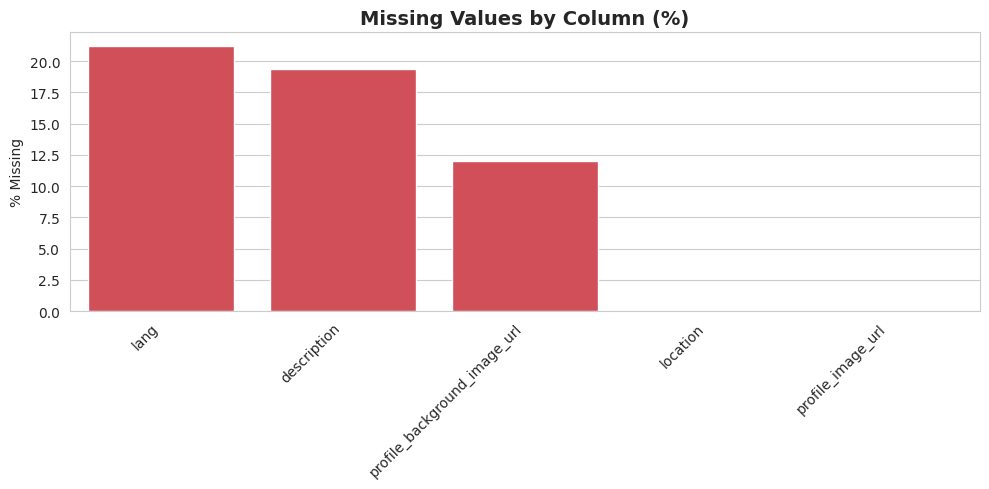

In [11]:
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(x=missing_df.index, y="missing_pct", data=missing_df, ax=ax, color="#E63946")
    ax.set_title("Missing Values by Column (%)")
    ax.set_ylabel("% Missing")
    ax.set_xlabel("")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values detected.")

 Columns such as `description` and `location` are free-text/user-entered fields



In [12]:
print("=== Duplicate Rows ===")
n_duplicates = df.duplicated().sum()
print(f"Fully duplicated rows: {n_duplicates}")

if "id" in df.columns:
    n_duplicate_ids = df["id"].duplicated().sum()
    print(f"Duplicate account IDs: {n_duplicate_ids}")

=== Duplicate Rows ===
Fully duplicated rows: 0
Duplicate account IDs: 0


=== Target Class Distribution ===
              count  percentage
account_type                   
human         25013       66.81
bot           12425       33.19


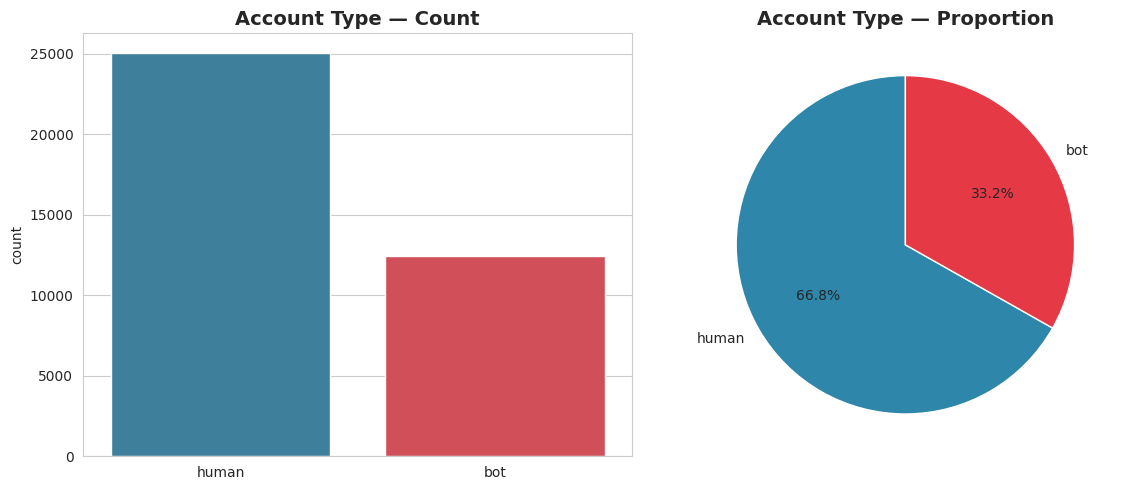

In [13]:
print("=== Target Class Distribution ===")
class_counts = df["account_type"].value_counts()
class_pct = df["account_type"].value_counts(normalize=True).mul(100).round(2)
print(pd.DataFrame({"count": class_counts, "percentage": class_pct}))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x="account_type", data=df, palette=PALETTE, ax=axes[0],
              order=class_counts.index)
axes[0].set_title("Account Type — Count")
axes[0].set_xlabel("")

axes[1].pie(class_counts, labels=class_counts.index, autopct="%1.1f%%",
            colors=[PALETTE.get(c, "#999999") for c in class_counts.index], startangle=90)
axes[1].set_title("Account Type — Proportion")

plt.tight_layout()
plt.show()

In [14]:
print("=== Data Types Summary ===")
dtype_summary = df.dtypes.value_counts()
print(dtype_summary)
print()
print("Numerical columns:", list(df.select_dtypes(include=np.number).columns))
print()
print("Categorical / object columns:", list(df.select_dtypes(include="object").columns))
print()
print("Boolean columns:", list(df.select_dtypes(include="bool").columns))

=== Data Types Summary ===
object     8
int64      7
bool       4
float64    1
Name: count, dtype: int64

Numerical columns: ['Unnamed: 0', 'favourites_count', 'followers_count', 'friends_count', 'id', 'statuses_count', 'average_tweets_per_day', 'account_age_days']

Categorical / object columns: ['created_at', 'description', 'lang', 'location', 'profile_background_image_url', 'profile_image_url', 'screen_name', 'account_type']

Boolean columns: ['default_profile', 'default_profile_image', 'geo_enabled', 'verified']


In [15]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,37438.0,NaN,NaN,NaN,18718.5,10807.564026,0.0,9359.25,18718.5,28077.75,37437.0
created_at,37438,37430,2015-11-03 09:51:18,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default_profile,37438,2,False,21718,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default_profile_image,37438,2,False,36880,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,30181,29944,.,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
favourites_count,37438.0,NaN,NaN,NaN,12302.062183,33923.650237,0.0,362.0,2066.0,8879.0,885123.0
followers_count,37438.0,NaN,NaN,NaN,370309.830279,2470829.490772,0.0,35.0,365.0,8440.25,121641473.0
friends_count,37438.0,NaN,NaN,NaN,4445.925183,49545.202489,0.0,37.0,296.0,893.0,4343060.0
geo_enabled,37438,2,False,20361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id,37438.0,NaN,NaN,NaN,122153596895032256.0,300431308900417472.0,418.0,99573057.5,399147423.5,2453825953.25,1120973992754581504.0


<a id="section5"></a>
# 5. Data Cleaning


| Action | Column(s) | Reason |
|---|---|---|
| Drop | `Unnamed: 0` | Artifact index column from CSV export, carries no information. |
| Drop | `id` | Unique account identifier — pure noise for a generalizable model (would cause leakage/overfitting if encoded). |
| Drop | `profile_background_image_url`, `profile_image_url` | Raw URLs to images; the *presence* of a custom image is already captured by `default_profile_image`, so the URL strings themselves add no usable signal without image analysis (out of scope here). |
| Drop | `screen_name` | The handle/username is account-specific and not a generalizable behavioral signal; using it risks the model memorizing specific accounts instead of learning patterns. |
| Engineer then drop | `location` | Free text with high cardinality and missingness. We extract a binary `has_location` flag (a behavioral signal — bots are likelier to skip optional profile fields) and drop the raw text. |
| Engineer then drop | `created_at` | Already distilled into `account_age_days`, so we keep the engineered numeric feature and drop the raw timestamp to avoid redundancy. |
| Impute | `description` | Missing bios are filled with an empty string `""` rather than dropped — *not* having a bio is itself a meaningful, common signal (see `has_description` in Section 8), and dropping rows would needlessly shrink the dataset. |
| Impute | `lang` | Missing language tags are filled with the literal string `"unknown"`, preserving them as their own category rather than guessing. |
| Drop duplicates | full-row duplicates | Identical rows add no new information and can bias training toward duplicated examples. |


In [16]:
df_clean = df.copy()

# --- 1. Drop uninformative / leakage-prone identifier columns ---
cols_to_drop = [
    "Unnamed: 0",
    "id",
    "profile_background_image_url",
    "profile_image_url",
    "screen_name",
]
cols_to_drop = [c for c in cols_to_drop if c in df_clean.columns]
df_clean = df_clean.drop(columns=cols_to_drop)
print(f"Dropped columns: {cols_to_drop}")
print(f"Shape after dropping identifier columns: {df_clean.shape}")

Dropped columns: ['Unnamed: 0', 'id', 'profile_background_image_url', 'profile_image_url', 'screen_name']
Shape after dropping identifier columns: (37438, 15)


In [17]:
# --- 2. Remove full-row duplicates ---
before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
after = len(df_clean)
print(f"Removed {before - after} duplicate rows ({before} -> {after})")

Removed 0 duplicate rows (37438 -> 37438)


In [18]:
# --- 3. Engineer has_location, then drop raw location text ---
if "location" in df_clean.columns:
    df_clean["has_location"] = df_clean["location"].notna() & (df_clean["location"].str.strip() != "")
    df_clean["has_location"] = df_clean["has_location"].astype(int)
    df_clean = df_clean.drop(columns=["location"])
    print("Engineered 'has_location' from 'location' and dropped the raw text column.")

Engineered 'has_location' from 'location' and dropped the raw text column.


In [19]:
# --- 4. Parse created_at (kept temporarily for EDA), then drop after EDA section ---
if "created_at" in df_clean.columns:
    df_clean["created_at_parsed"] = pd.to_datetime(df_clean["created_at"], errors="coerce")
    df_clean["account_created_year"] = df_clean["created_at_parsed"].dt.year
    print("Parsed 'created_at' into 'account_created_year' for exploratory use.")
    print("(Raw 'created_at' and the parsed timestamp will be dropped before modeling — "
          "'account_age_days' already encodes this information numerically.)")

Parsed 'created_at' into 'account_created_year' for exploratory use.
(Raw 'created_at' and the parsed timestamp will be dropped before modeling — 'account_age_days' already encodes this information numerically.)


In [20]:
# --- 5. Impute missing description and lang ---
df_clean["description"] = df_clean["description"].fillna("")
if "lang" in df_clean.columns:
    df_clean["lang"] = df_clean["lang"].fillna("unknown")

print("Remaining missing values after cleaning:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Remaining missing values after cleaning:
Series([], dtype: int64)


In [21]:
# --- 6. Normalize boolean columns to 0/1 ints (some CSV exports store these as strings) ---
bool_like_cols = ["default_profile", "default_profile_image", "geo_enabled", "verified"]
for c in bool_like_cols:
    if c in df_clean.columns:
        if df_clean[c].dtype == object:
            df_clean[c] = df_clean[c].map({"True": 1, "False": 0, True: 1, False: 0}).fillna(0)
        df_clean[c] = df_clean[c].astype(int)

print(df_clean[[c for c in bool_like_cols if c in df_clean.columns]].dtypes)

default_profile          int64
default_profile_image    int64
geo_enabled              int64
verified                 int64
dtype: object


In [22]:
# --- 7. Encode target as binary for modeling, keep readable label for EDA/plots ---
df_clean["account_type"] = df_clean["account_type"].str.strip().str.lower()
df_clean["target"] = df_clean["account_type"].map({"human": 0, "bot": 1})

assert df_clean["target"].isnull().sum() == 0, "Unexpected label found in account_type"

print("Final cleaned shape:", df_clean.shape)
df_clean.head()

Final cleaned shape: (37438, 18)


,created_at,default_profile,default_profile_image,description,favourites_count,followers_count,friends_count,geo_enabled,lang,statuses_count,verified,average_tweets_per_day,account_age_days,account_type,has_location,created_at_parsed,account_created_year,target
0,2016-10-15 21:32:11,0,0,"Blame @xaiax, Inspired by @MakingInvisible, us...",4,1589,4,0,en,11041,0,7.870,1403,bot,1,2016-10-15 21:32:11,2016,1
1,2016-11-09 05:01:30,0,0,Photographing the American West since 1980. I ...,536,860,880,0,en,252,0,0.183,1379,human,1,2016-11-09 05:01:30,2016,0
2,2017-06-17 05:34:27,0,0,Scruffy looking nerf herder and @twitch broadc...,3307,172,594,1,en,1001,0,0.864,1159,human,1,2017-06-17 05:34:27,2017,0
3,2016-07-21 13:32:25,1,0,Wife.Godmother.Friend.Feline Fanatic! Assistan...,8433,517,633,1,en,1324,0,0.889,1489,human,1,2016-07-21 13:32:25,2016,0
4,2012-01-15 16:32:35,0,0,Loan coach at @mancity & Aspiring DJ,88,753678,116,1,en,4202,1,1.339,3138,human,1,2012-01-15 16:32:35,2012,0


<a id="section6"></a>
# 6. Exploratory Data Analysis



In [23]:
eda = df_clean.copy()
NUMERIC_EDA_COLS = ["followers_count", "friends_count", "statuses_count",
                     "average_tweets_per_day", "account_age_days", "favourites_count"]
NUMERIC_EDA_COLS = [c for c in NUMERIC_EDA_COLS if c in eda.columns]
print("Numeric columns for EDA:", NUMERIC_EDA_COLS)

Numeric columns for EDA: ['followers_count', 'friends_count', 'statuses_count', 'average_tweets_per_day', 'account_age_days', 'favourites_count']


## 6.1 Distributions of Core Numeric Features (Histograms)

Count-based Twitter features are typically extremely right-skewed (a small number of accounts have huge
follower counts), so we plot both raw and log1p-transformed distributions.


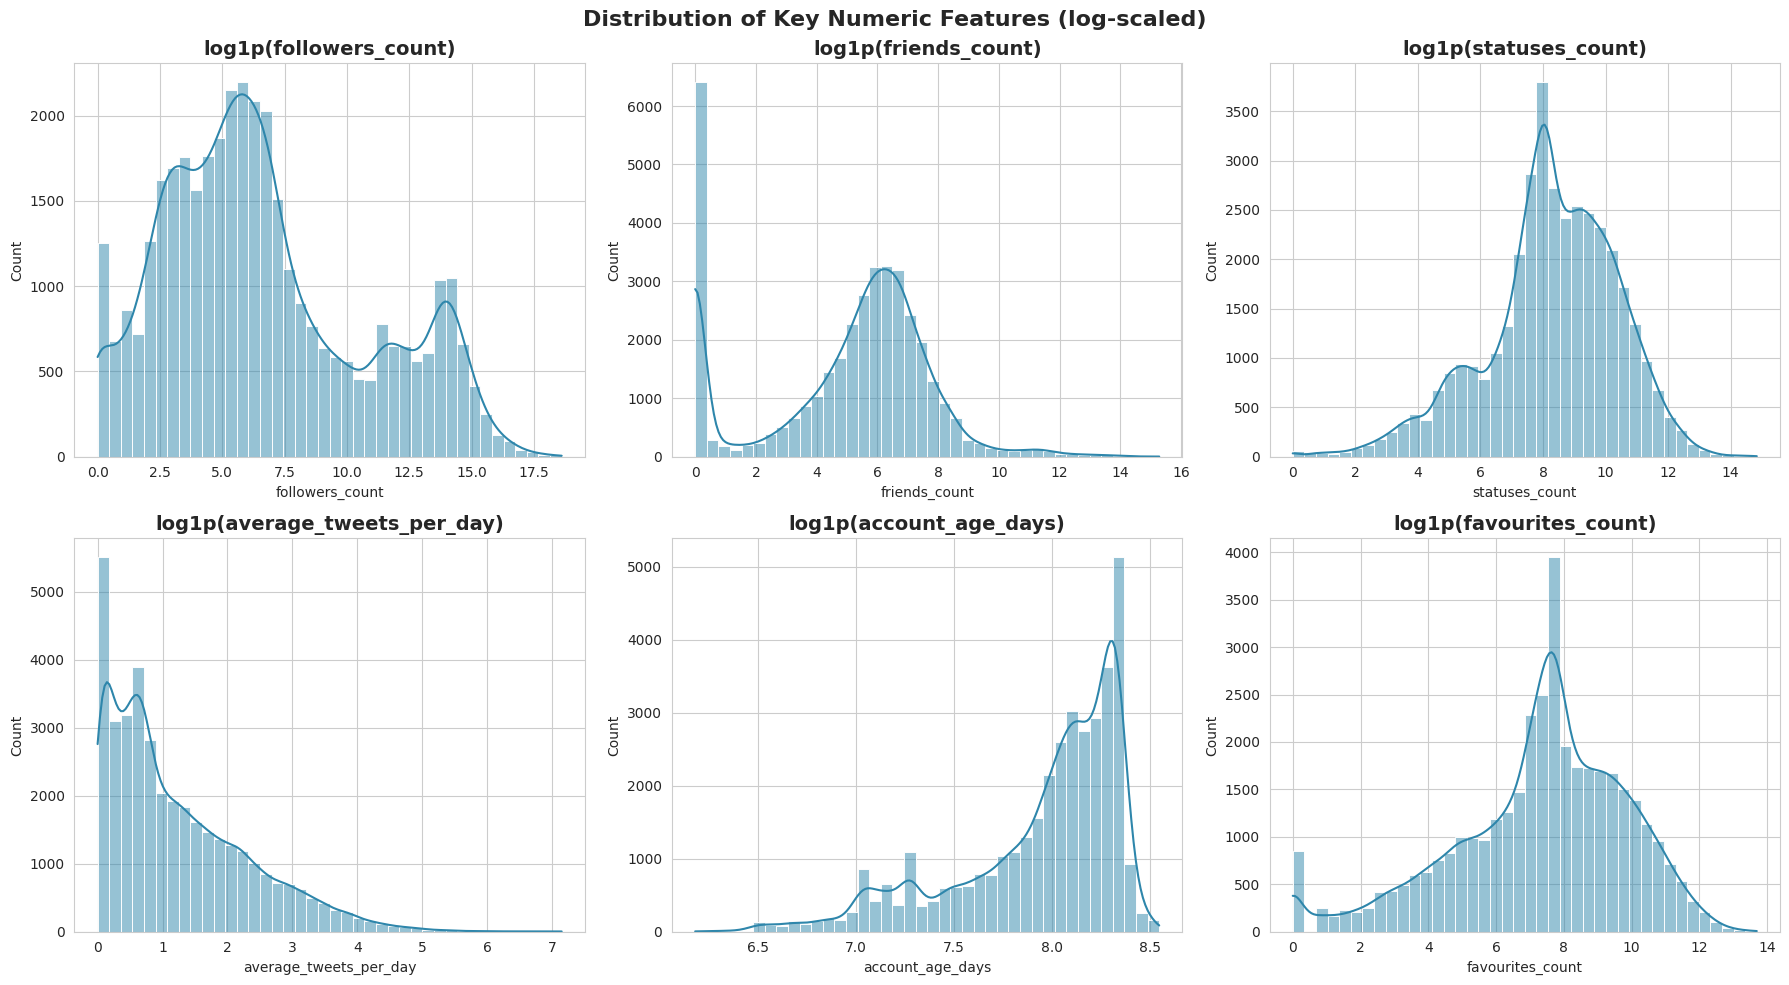

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(NUMERIC_EDA_COLS):
    sns.histplot(np.log1p(eda[col]), bins=40, kde=True, ax=axes[i], color="#2E86AB")
    axes[i].set_title(f"log1p({col})")
plt.suptitle("Distribution of Key Numeric Features (log-scaled)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## 6.2 Numeric Features by Account Type (Boxplots)


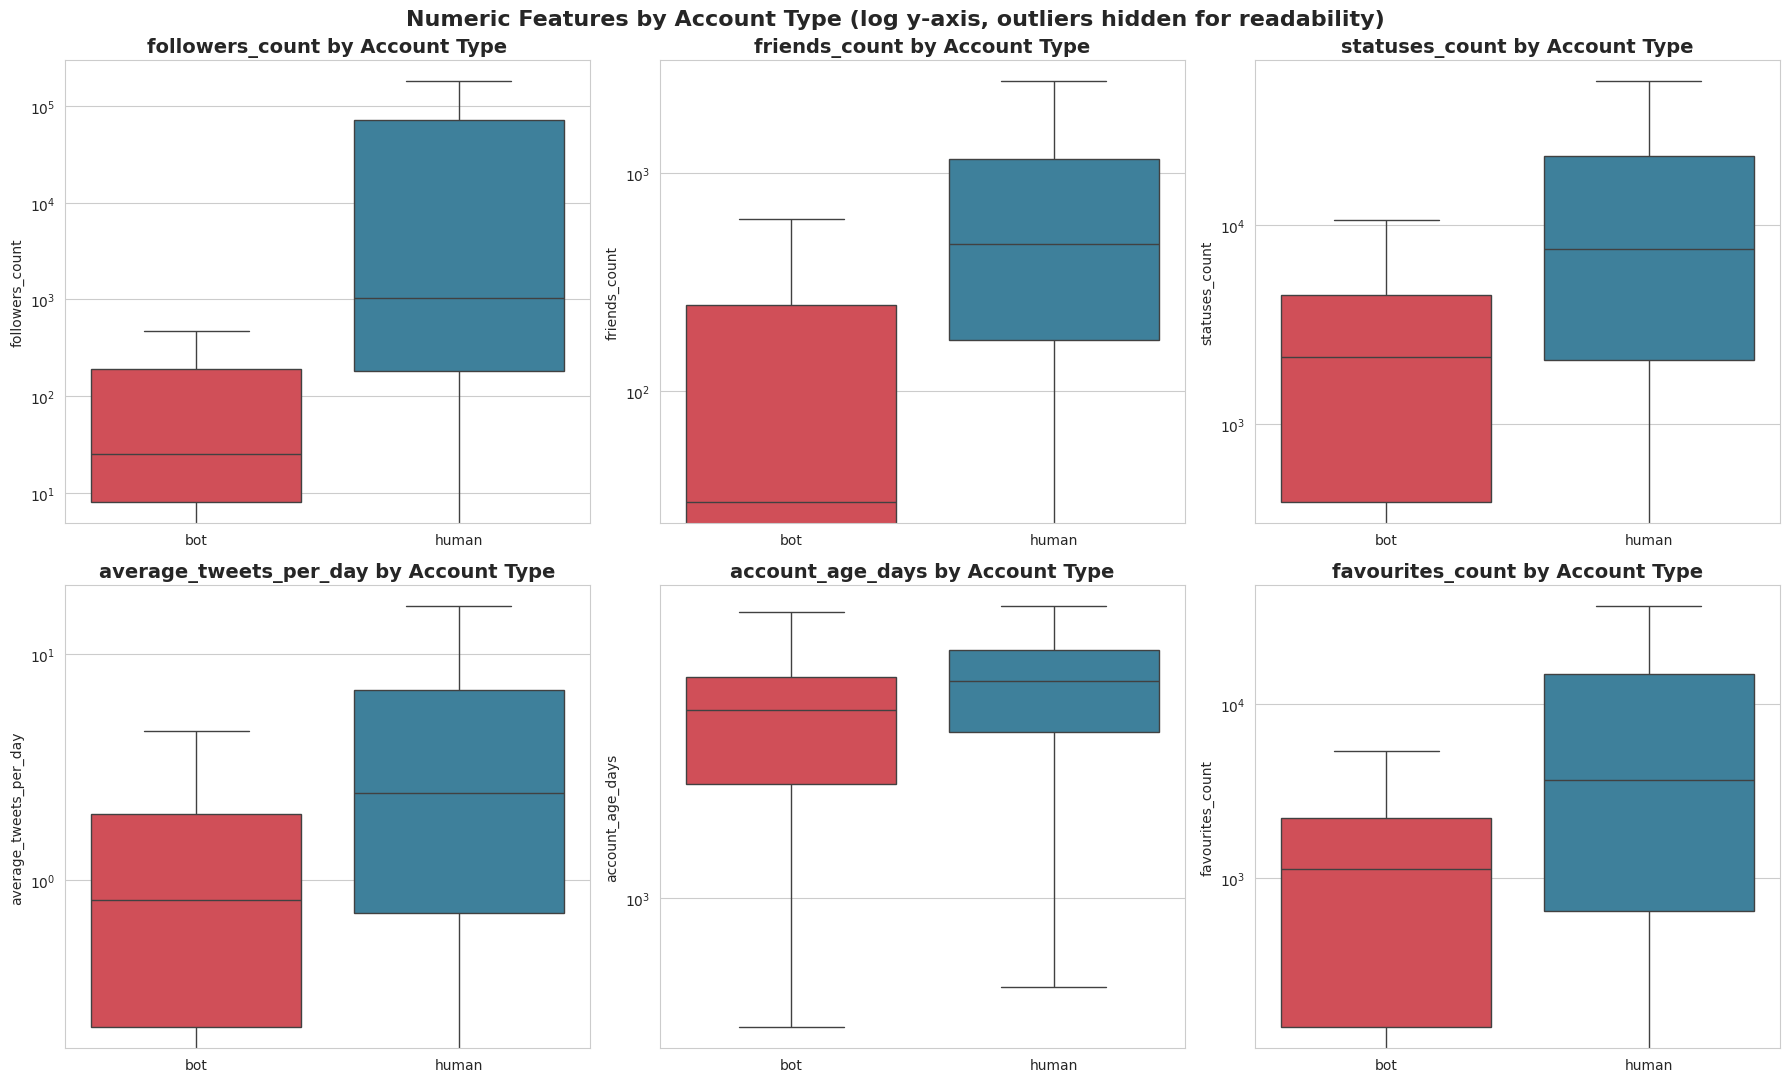

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
for i, col in enumerate(NUMERIC_EDA_COLS):
    sns.boxplot(x="account_type", y=col, data=eda, ax=axes[i], palette=PALETTE,
                showfliers=False)
    axes[i].set_yscale("log")
    axes[i].set_title(f"{col} by Account Type")
    axes[i].set_xlabel("")
plt.suptitle("Numeric Features by Account Type (log y-axis, outliers hidden for readability)",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## 6.3 Average Tweets per Day — A Closer Look




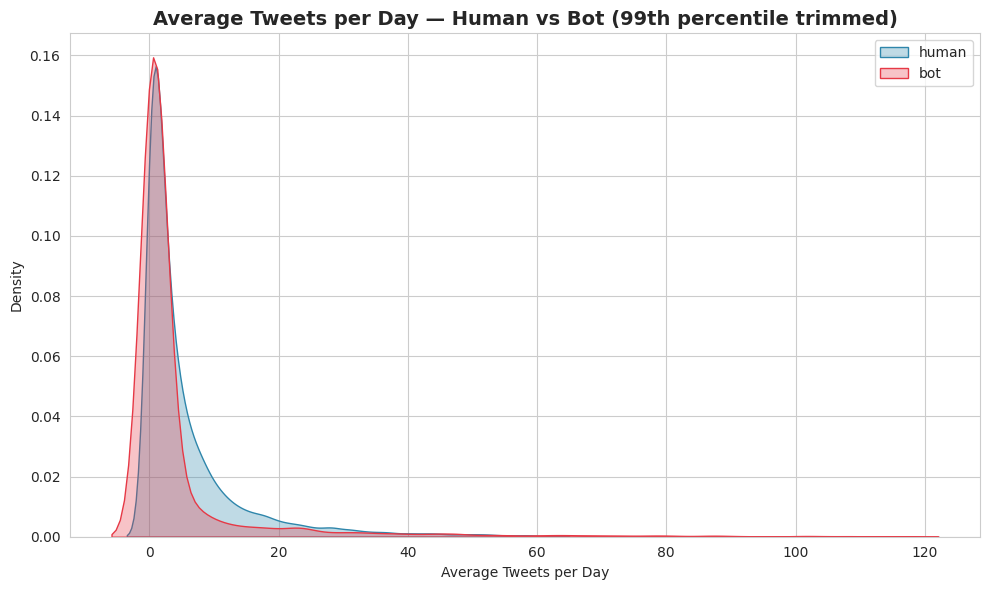

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))
for label, color in PALETTE.items():
    subset = eda[eda["account_type"] == label]["average_tweets_per_day"]
    subset = subset[subset < subset.quantile(0.99)]  # trim extreme outliers for visibility
    sns.kdeplot(subset, label=label, color=color, fill=True, alpha=0.3, ax=ax)
ax.set_title("Average Tweets per Day — Human vs Bot (99th percentile trimmed)")
ax.set_xlabel("Average Tweets per Day")
ax.legend()
plt.tight_layout()
plt.show()

## 6.4 Account Age Distribution


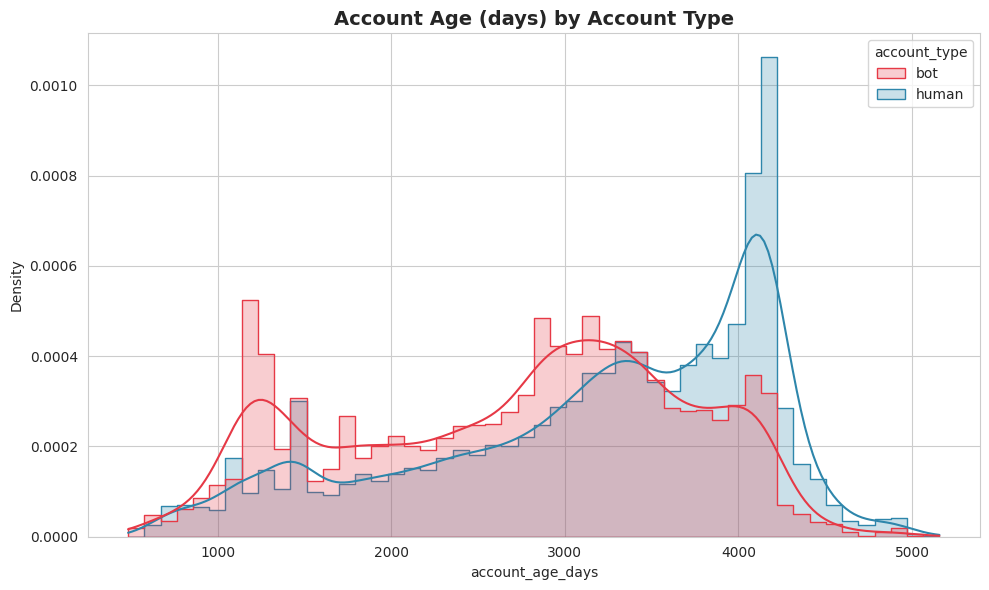

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=eda, x="account_age_days", hue="account_type", palette=PALETTE,
             bins=50, kde=True, element="step", stat="density", common_norm=False, ax=ax)
ax.set_title("Account Age (days) by Account Type")
plt.tight_layout()
plt.show()

## 6.5 Categorical / Binary Flags (Countplots)



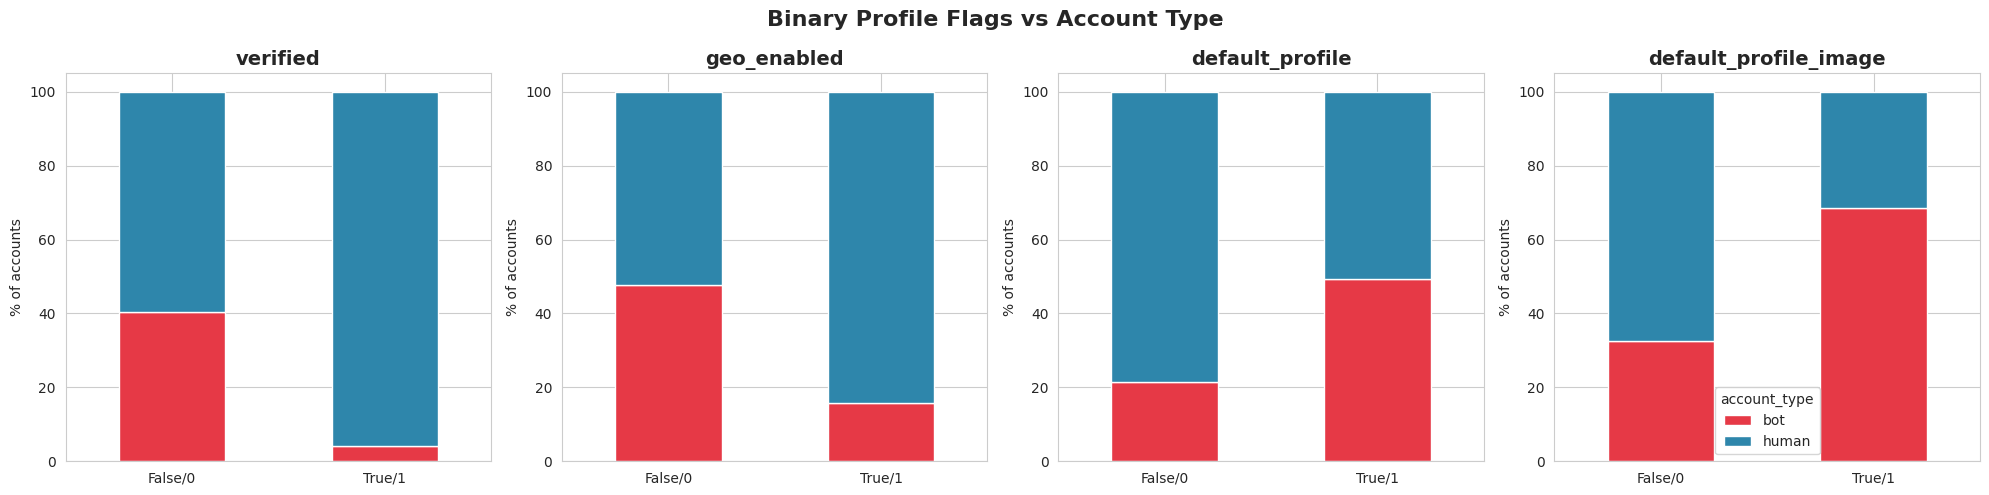

In [28]:
binary_flags = [c for c in ["verified", "geo_enabled", "default_profile", "default_profile_image"]
                if c in eda.columns]

fig, axes = plt.subplots(1, len(binary_flags), figsize=(5 * len(binary_flags), 5))
if len(binary_flags) == 1:
    axes = [axes]
for i, col in enumerate(binary_flags):
    ct = pd.crosstab(eda[col], eda["account_type"], normalize="index") * 100
    ct.plot(kind="bar", stacked=True, ax=axes[i], color=[PALETTE["bot"], PALETTE["human"]],
            legend=(i == len(binary_flags) - 1))
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("% of accounts")
    axes[i].set_xticklabels(["False/0", "True/1"], rotation=0)
plt.suptitle("Binary Profile Flags vs Account Type", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## 6.6 Language Distribution


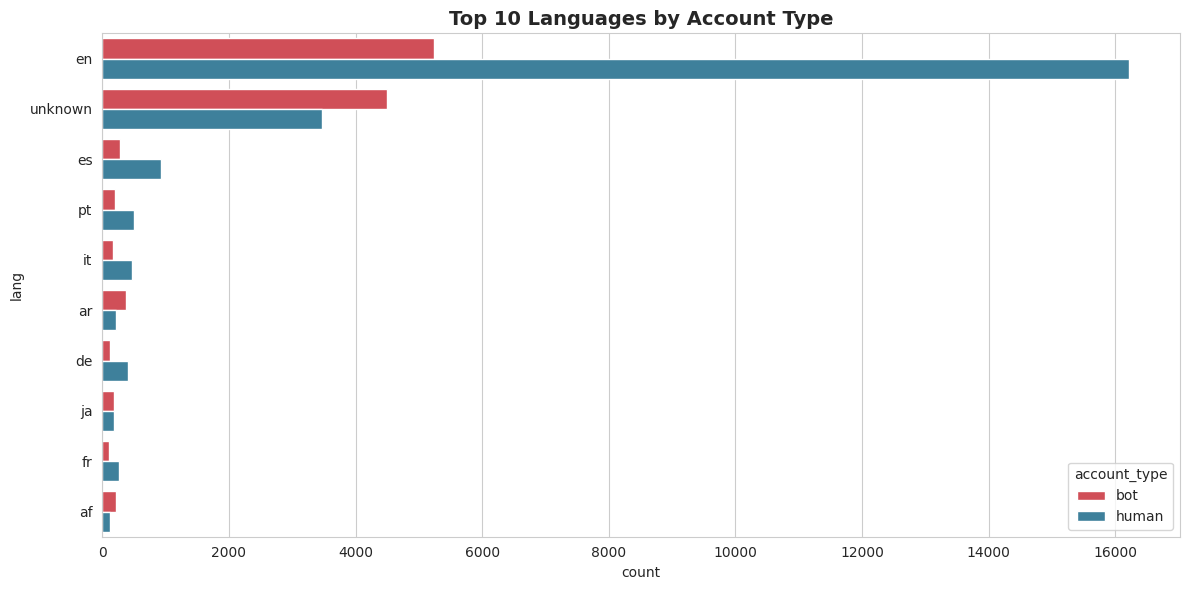

In [29]:
if "lang" in eda.columns:
    top_langs = eda["lang"].value_counts().head(10).index
    lang_subset = eda[eda["lang"].isin(top_langs)]

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.countplot(data=lang_subset, y="lang", hue="account_type", palette=PALETTE,
                  order=top_langs, ax=ax)
    ax.set_title("Top 10 Languages by Account Type")
    plt.tight_layout()
    plt.show()

## 6.7 `has_location` vs Account Type


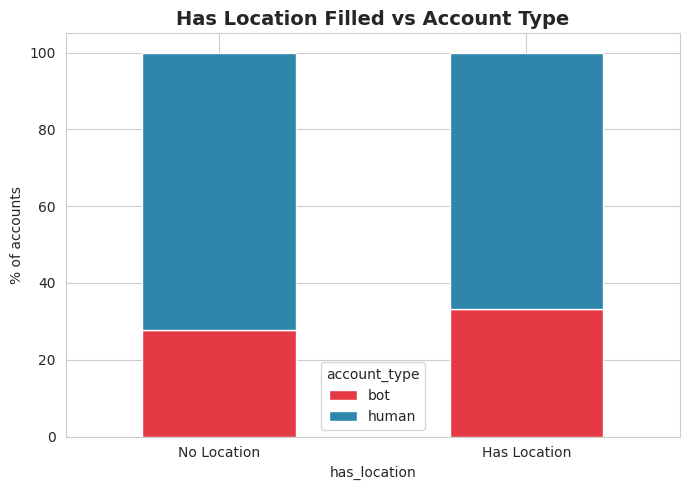

In [30]:
if "has_location" in eda.columns:
    ct = pd.crosstab(eda["has_location"], eda["account_type"], normalize="index") * 100
    fig, ax = plt.subplots(figsize=(7, 5))
    ct.plot(kind="bar", stacked=True, ax=ax, color=[PALETTE["bot"], PALETTE["human"]])
    ax.set_title("Has Location Filled vs Account Type")
    ax.set_xticklabels(["No Location", "Has Location"], rotation=0)
    ax.set_ylabel("% of accounts")
    plt.tight_layout()
    plt.show()

## 6.8 Correlation Heatmap (Numeric Features)


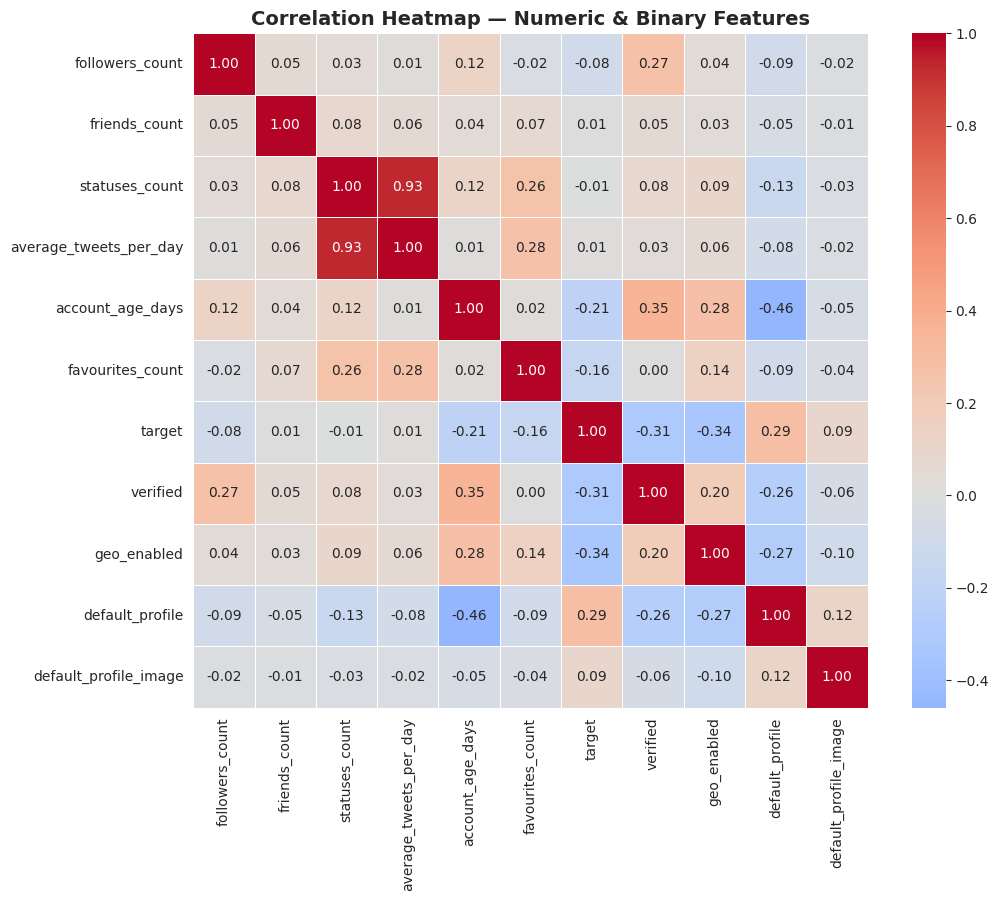

In [31]:
corr_cols = NUMERIC_EDA_COLS + [c for c in ["target"] if c in eda.columns]
corr_cols += [c for c in binary_flags if c in eda.columns]
corr_cols = list(dict.fromkeys(corr_cols))  # de-duplicate, preserve order

corr_matrix = eda[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax, square=True)
ax.set_title("Correlation Heatmap — Numeric & Binary Features")
plt.tight_layout()
plt.show()

<a id="section7"></a>
# 7. Experiment 1 — Baseline Model (Structured Data Only)



In [32]:
def evaluate_classification(y_true, y_pred, y_score):
    '''Compute the standard classification metrics used across all experiments.'''
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_true, y_score),
    }


def get_score(model, X):
    '''Return a probability-like score for ROC AUC, regardless of whether the
    model exposes predict_proba or decision_function.'''
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)


def train_evaluate_models(models_dict, X_train, X_test, y_train, y_test, sort_by="F1 Score"):
    '''Fit each model in models_dict, evaluate on the test set, and return a
    leaderboard DataFrame (sorted) plus a dict of fitted models.'''
    rows = []
    fitted_models = {}
    for name, model in models_dict.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_score = get_score(model, X_test)
        metrics = evaluate_classification(y_test, y_pred, y_score)
        metrics["Model"] = name
        rows.append(metrics)
        fitted_models[name] = model

    leaderboard = pd.DataFrame(rows)[["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]]
    leaderboard = leaderboard.sort_values(sort_by, ascending=False).reset_index(drop=True)
    return leaderboard, fitted_models


def style_leaderboard(leaderboard):
    return (leaderboard.style
            .background_gradient(subset=["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"],
                                  cmap="Greens")
            .format({"Accuracy": "{:.4f}", "Precision": "{:.4f}", "Recall": "{:.4f}",
                     "F1 Score": "{:.4f}", "ROC AUC": "{:.4f}"}))


def plot_leaderboard(leaderboard, title):
    fig, ax = plt.subplots(figsize=(10, 5))
    plot_df = leaderboard.melt(id_vars="Model", var_name="Metric", value_name="Score")
    sns.barplot(data=plot_df, x="Score", y="Model", hue="Metric", ax=ax)
    ax.set_title(title)
    ax.set_xlim(0, 1)
    plt.tight_layout()
    plt.show()


def get_model_zoo(random_state=RANDOM_STATE):
    '''Fresh, unfitted instances of the standard structured-data model zoo,
    used for both Experiment 1 and Experiment 2.'''
    return {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=random_state),
        "Random Forest": RandomForestClassifier(n_estimators=300, random_state=random_state, n_jobs=-1),
        "XGBoost": xgb.XGBClassifier(
            n_estimators=300, eval_metric="logloss", random_state=random_state,
            use_label_encoder=False, n_jobs=-1,
        ),
        "LightGBM": lgb.LGBMClassifier(n_estimators=300, random_state=random_state, n_jobs=-1, verbose=-1),
        "CatBoost": cb.CatBoostClassifier(iterations=300, random_state=random_state, verbose=0),
    }

print("Modeling utilities defined.")

Modeling utilities defined.


## 7.1 Feature Selection



In [33]:
EXPERIMENT1_DROP_COLS = ["description", "created_at", "created_at_parsed",
                          "account_created_year", "account_type", "target"]
EXPERIMENT1_DROP_COLS = [c for c in EXPERIMENT1_DROP_COLS if c in df_clean.columns]

exp1_df = df_clean.drop(columns=EXPERIMENT1_DROP_COLS).copy()
print("Experiment 1 feature columns:")
print(list(exp1_df.columns))

Experiment 1 feature columns:
['default_profile', 'default_profile_image', 'favourites_count', 'followers_count', 'friends_count', 'geo_enabled', 'lang', 'statuses_count', 'verified', 'average_tweets_per_day', 'account_age_days', 'has_location']


## 7.2 Encode Categorical Variables



In [34]:
y = df_clean["target"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    exp1_df, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train size: {X_train_raw.shape}, Test size: {X_test_raw.shape}")
print(f"Train class balance:\n{y_train.value_counts(normalize=True)}")

Train size: (29950, 12), Test size: (7488, 12)
Train class balance:
target
0    0.668114
1    0.331886
Name: proportion, dtype: float64


In [35]:
def frequency_encode_fit(train_series):
    return train_series.value_counts(normalize=True).to_dict()

def frequency_encode_transform(series, freq_map, default=0.0):
    return series.map(freq_map).fillna(default)

X_train_1 = X_train_raw.copy()
X_test_1 = X_test_raw.copy()

if "lang" in X_train_1.columns:
    lang_freq_map = frequency_encode_fit(X_train_1["lang"])
    X_train_1["lang_encoded"] = frequency_encode_transform(X_train_1["lang"], lang_freq_map)
    X_test_1["lang_encoded"] = frequency_encode_transform(X_test_1["lang"], lang_freq_map)
    X_train_1 = X_train_1.drop(columns=["lang"])
    X_test_1 = X_test_1.drop(columns=["lang"])

print("Encoded feature columns:", list(X_train_1.columns))

Encoded feature columns: ['default_profile', 'default_profile_image', 'favourites_count', 'followers_count', 'friends_count', 'geo_enabled', 'statuses_count', 'verified', 'average_tweets_per_day', 'account_age_days', 'has_location', 'lang_encoded']


## 7.3 Scale Numerical Variables



In [36]:
scaler_exp1 = StandardScaler()
X_train_1_scaled = pd.DataFrame(
    scaler_exp1.fit_transform(X_train_1), columns=X_train_1.columns, index=X_train_1.index
)
X_test_1_scaled = pd.DataFrame(
    scaler_exp1.transform(X_test_1), columns=X_test_1.columns, index=X_test_1.index
)

X_train_1_scaled.head()

,default_profile,default_profile_image,favourites_count,followers_count,friends_count,geo_enabled,statuses_count,verified,average_tweets_per_day,account_age_days,has_location,lang_encoded
4894,1.175381,-0.122529,-0.300474,0.005081,-0.059308,1.091517,0.401525,-0.501147,0.281891,0.413667,0.024523,-1.447442
35546,1.175381,-0.122529,-0.301379,-0.147634,-0.088648,-0.916156,-0.268536,-0.501147,-0.244546,0.833392,0.024523,-0.683391
18027,-0.850788,-0.122529,-0.308764,-0.056720,1.424269,1.091517,2.154107,-0.501147,1.899566,0.022583,0.024523,-1.447442
15817,-0.850788,-0.122529,-0.348811,-0.142834,-0.082234,1.091517,-0.158973,1.995421,-0.179485,1.280770,0.024523,0.832127
4860,-0.850788,-0.122529,1.194224,-0.147273,-0.021893,-0.916156,1.048900,-0.501147,1.438307,-0.879085,0.024523,0.832127


## 7.4 Train Models


In [37]:
models_exp1 = get_model_zoo()
baseline_results, fitted_models_exp1 = train_evaluate_models(
    models_exp1, X_train_1_scaled, X_test_1_scaled, y_train, y_test
)
print("Experiment 1 — Baseline Leaderboard (sorted by F1 Score)")
style_leaderboard(baseline_results)

Experiment 1 — Baseline Leaderboard (sorted by F1 Score)


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,LightGBM,0.8814,0.8513,0.7787,0.8134,0.9391
1,CatBoost,0.8814,0.8550,0.7738,0.8124,0.9378
2,Random Forest,0.8809,0.8612,0.7642,0.8098,0.9369
3,XGBoost,0.8786,0.8453,0.7763,0.8093,0.9325
4,Logistic Regression,0.7568,0.6426,0.6020,0.6216,0.8197


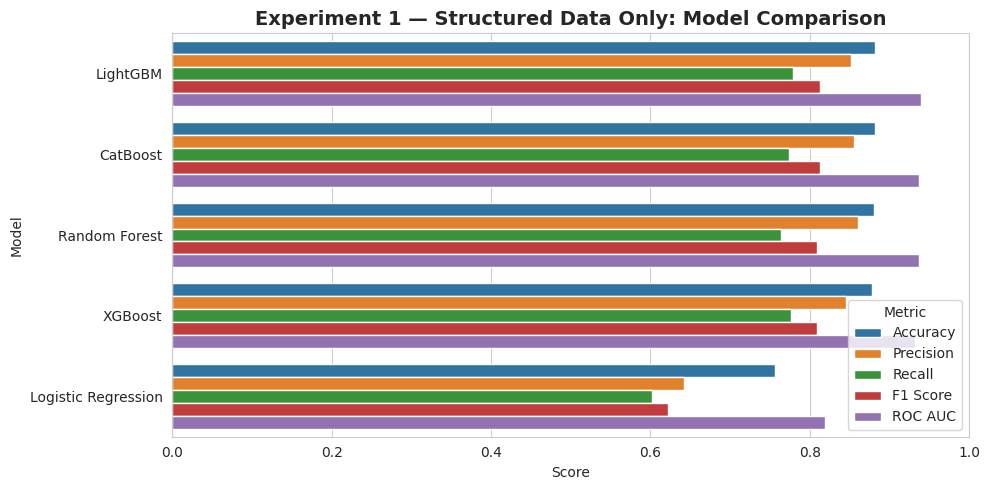

In [38]:
plot_leaderboard(baseline_results, "Experiment 1 — Structured Data Only: Model Comparison")

## 7.5 Confusion Matrix — Best Baseline Model


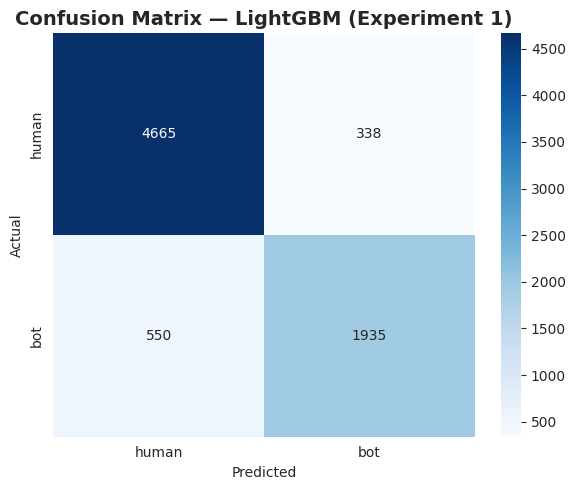

              precision    recall  f1-score   support

       human       0.89      0.93      0.91      5003
         bot       0.85      0.78      0.81      2485

    accuracy                           0.88      7488
   macro avg       0.87      0.86      0.86      7488
weighted avg       0.88      0.88      0.88      7488



In [39]:
best_model_name_exp1 = baseline_results.iloc[0]["Model"]
best_model_exp1 = fitted_models_exp1[best_model_name_exp1]
y_pred_best_exp1 = best_model_exp1.predict(X_test_1_scaled)

cm = confusion_matrix(y_test, y_pred_best_exp1)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["human", "bot"], yticklabels=["human", "bot"], ax=ax)
ax.set_title(f"Confusion Matrix — {best_model_name_exp1} (Experiment 1)")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_best_exp1, target_names=["human", "bot"]))

<a id="section8"></a>
# 8. Description Feature Engineering




In [40]:
def engineer_description_features(text_series):
    '''Extract interpretable numeric features from a Series of bio/description text.'''
    text_series = text_series.fillna("").astype(str)

    features = pd.DataFrame(index=text_series.index)
    features["bio_length"] = text_series.str.len()
    features["bio_word_count"] = text_series.str.split().apply(len)
    features["has_description"] = (text_series.str.strip() != "").astype(int)
    features["mention_count"] = text_series.str.count(r"@\w+")
    features["url_count"] = text_series.str.count(r"http\S+|www\.\S+")
    features["has_url"] = (features["url_count"] > 0).astype(int)

    def uppercase_ratio(s):
        letters = [c for c in s if c.isalpha()]
        if len(letters) == 0:
            return 0.0
        return sum(1 for c in letters if c.isupper()) / len(letters)

    features["uppercase_ratio"] = text_series.apply(uppercase_ratio)
    features["digit_count"] = text_series.apply(lambda s: sum(c.isdigit() for c in s))
    features["special_character_count"] = text_series.apply(
        lambda s: sum(1 for c in s if not c.isalnum() and not c.isspace())
    )
    return features


description_features = engineer_description_features(df_clean["description"])
df_engineered = pd.concat([df_clean, description_features], axis=1)

print("Engineered description features:")
description_features.head()

Engineered description features:


,bio_length,bio_word_count,has_description,mention_count,url_count,has_url,uppercase_ratio,digit_count,special_character_count
0,129,18,1,2,0,0,0.066038,0,6
1,160,24,1,0,0,0,0.031746,4,7
2,81,10,1,2,0,0,0.029851,0,4
3,97,9,1,0,0,0,0.142857,0,5
4,36,7,1,1,0,0,0.142857,0,2


## 8.1 Humans vs Bots — Engineered Bio Features


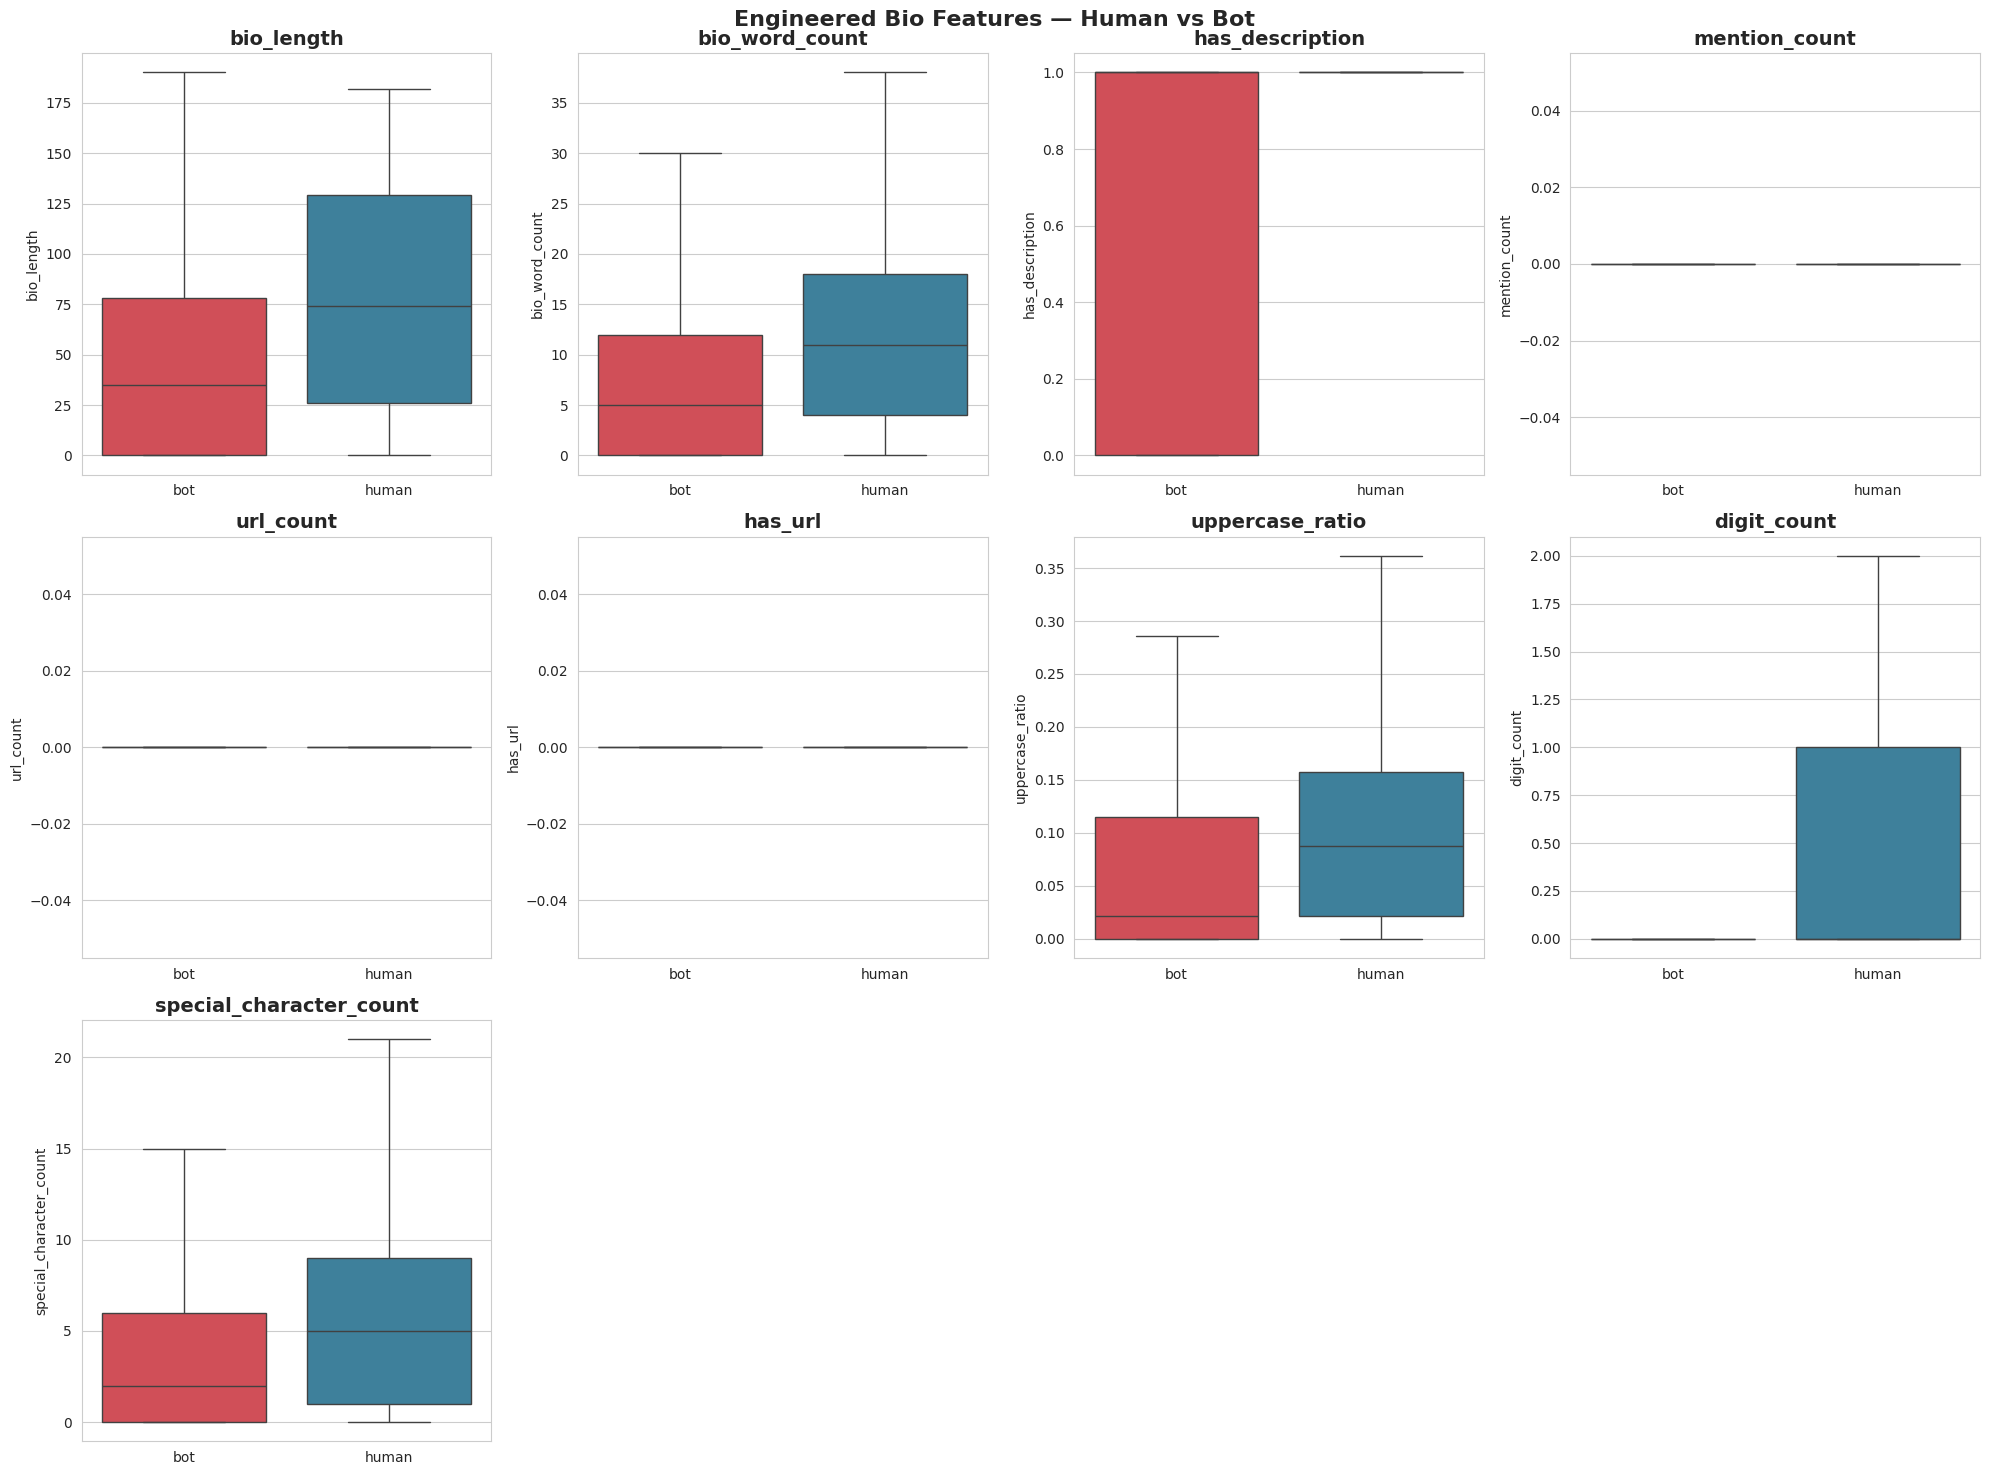

In [42]:
engineered_cols = list(description_features.columns)

n_cols = 4
n_rows = (len(engineered_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(engineered_cols):
    sns.boxplot(x="account_type", y=col, data=df_engineered,
                ax=axes[i], palette=PALETTE, showfliers=False)
    axes[i].set_title(col)
    axes[i].set_xlabel("")

for ax in axes[i+1:]:
    ax.remove()

plt.suptitle("Engineered Bio Features — Human vs Bot", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
print("Mean engineered feature values by account type:")
df_engineered.groupby("account_type")[engineered_cols].mean().T

<a id="section9"></a>
# 9. Experiment 2 — Structured Data + Description Features




In [43]:
EXPERIMENT2_DROP_COLS = ["description", "created_at", "created_at_parsed",
                          "account_created_year", "account_type", "target"]
EXPERIMENT2_DROP_COLS = [c for c in EXPERIMENT2_DROP_COLS if c in df_engineered.columns]

exp2_df = df_engineered.drop(columns=EXPERIMENT2_DROP_COLS).copy()
print(f"Experiment 2 feature columns ({len(exp2_df.columns)} total):")
print(list(exp2_df.columns))

Experiment 2 feature columns (21 total):
['default_profile', 'default_profile_image', 'favourites_count', 'followers_count', 'friends_count', 'geo_enabled', 'lang', 'statuses_count', 'verified', 'average_tweets_per_day', 'account_age_days', 'has_location', 'bio_length', 'bio_word_count', 'has_description', 'mention_count', 'url_count', 'has_url', 'uppercase_ratio', 'digit_count', 'special_character_count']


In [44]:
X_train_raw2, X_test_raw2, y_train2, y_test2 = train_test_split(
    exp2_df, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train_2 = X_train_raw2.copy()
X_test_2 = X_test_raw2.copy()

if "lang" in X_train_2.columns:
    lang_freq_map_2 = frequency_encode_fit(X_train_2["lang"])
    X_train_2["lang_encoded"] = frequency_encode_transform(X_train_2["lang"], lang_freq_map_2)
    X_test_2["lang_encoded"] = frequency_encode_transform(X_test_2["lang"], lang_freq_map_2)
    X_train_2 = X_train_2.drop(columns=["lang"])
    X_test_2 = X_test_2.drop(columns=["lang"])

scaler_exp2 = StandardScaler()
X_train_2_scaled = pd.DataFrame(
    scaler_exp2.fit_transform(X_train_2), columns=X_train_2.columns, index=X_train_2.index
)
X_test_2_scaled = pd.DataFrame(
    scaler_exp2.transform(X_test_2), columns=X_test_2.columns, index=X_test_2.index
)

print("Train shape:", X_train_2_scaled.shape, " Test shape:", X_test_2_scaled.shape)

Train shape: (29950, 21)  Test shape: (7488, 21)


In [45]:
models_exp2 = get_model_zoo()
engineered_feature_results, fitted_models_exp2 = train_evaluate_models(
    models_exp2, X_train_2_scaled, X_test_2_scaled, y_train2, y_test2
)
print("Experiment 2 — Structured + Description Features Leaderboard (sorted by F1 Score)")
style_leaderboard(engineered_feature_results)

Experiment 2 — Structured + Description Features Leaderboard (sorted by F1 Score)


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,LightGBM,0.8834,0.8585,0.7767,0.8156,0.9400
1,CatBoost,0.8810,0.8587,0.7678,0.8107,0.9393
2,XGBoost,0.8777,0.8401,0.7799,0.8088,0.9360
3,Random Forest,0.8758,0.8621,0.7449,0.7992,0.9364
4,Logistic Regression,0.7743,0.6845,0.5936,0.6358,0.8419


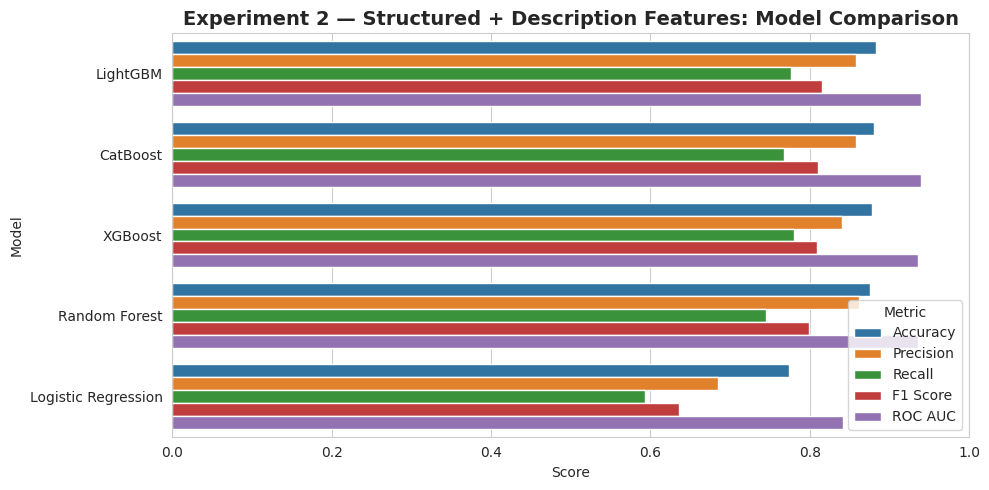

In [46]:
plot_leaderboard(engineered_feature_results,
                  "Experiment 2 — Structured + Description Features: Model Comparison")

## 9.1 Experiment 1 vs Experiment 2 — Direct Comparison


In [47]:
comparison_1_vs_2 = baseline_results.set_index("Model").add_suffix(" (Exp 1)").join(
    engineered_feature_results.set_index("Model").add_suffix(" (Exp 2)"), how="outer"
)

metric_deltas = pd.DataFrame(index=comparison_1_vs_2.index)
for metric in ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]:
    metric_deltas[f"Δ {metric}"] = (
        comparison_1_vs_2[f"{metric} (Exp 2)"] - comparison_1_vs_2[f"{metric} (Exp 1)"]
    )

print("Per-model change when adding description-derived features (Exp 2 - Exp 1):")
metric_deltas.style.format("{:+.4f}").background_gradient(cmap="RdYlGn", axis=None)

Per-model change when adding description-derived features (Exp 2 - Exp 1):


,Δ Accuracy,Δ Precision,Δ Recall,Δ F1 Score,Δ ROC AUC
Model,,,,,
CatBoost,-0.0004,+0.0036,-0.0060,-0.0017,+0.0016
LightGBM,+0.0020,+0.0072,-0.0020,+0.0022,+0.0009
Logistic Regression,+0.0175,+0.0418,-0.0085,+0.0141,+0.0223
Random Forest,-0.0051,+0.0009,-0.0193,-0.0106,-0.0005
XGBoost,-0.0009,-0.0053,+0.0036,-0.0005,+0.0035


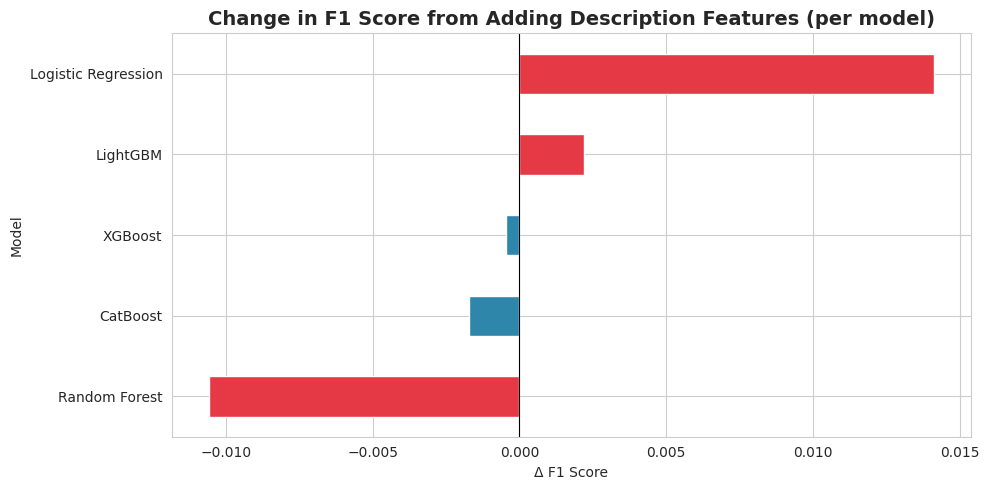

In [48]:
fig, ax = plt.subplots(figsize=(10, 5))
metric_deltas["Δ F1 Score"].sort_values().plot(kind="barh", ax=ax,
                                                 color=metric_deltas["Δ F1 Score"].apply(
                                                     lambda v: "#2E86AB" if v >= 0 else "#E63946"))
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Change in F1 Score from Adding Description Features (per model)")
ax.set_xlabel("Δ F1 Score")
plt.tight_layout()
plt.show()

<a id="section10"></a>
# 10. NLP Analysis — Cleaning, WordClouds & Word Frequencies



In [49]:
def clean_text(text):
    '''Lowercase, strip URLs/mentions/punctuation/digits, and remove stopwords.'''
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)        # remove URLs
    text = re.sub(r"@\w+", " ", text)                      # remove mentions
    text = re.sub(r"[%s]" % re.escape(string.punctuation), " ", text)  # remove punctuation
    text = re.sub(r"\d+", " ", text)                       # remove digits
    text = re.sub(r"\s+", " ", text).strip()                # collapse whitespace

    tokens = [w for w in text.split() if w not in STOPWORDS and len(w) > 1]
    return " ".join(tokens)


df_engineered["description_clean"] = df_engineered["description"].apply(clean_text)
df_engineered[["description", "description_clean"]].sample(5, random_state=RANDOM_STATE)

,description,description_clean
36730,accounting the uninteresting life of a teenage...,accounting uninteresting life teenage girl
25960,,
12307,melissa & liz | they/them | nocturnal queer cr...,melissa liz nocturnal queer cryptids make art ...
27357,,
7249,New Adventures in Wi-Fi.,new adventures wi fi


## 10.1 WordClouds — Human vs Bot


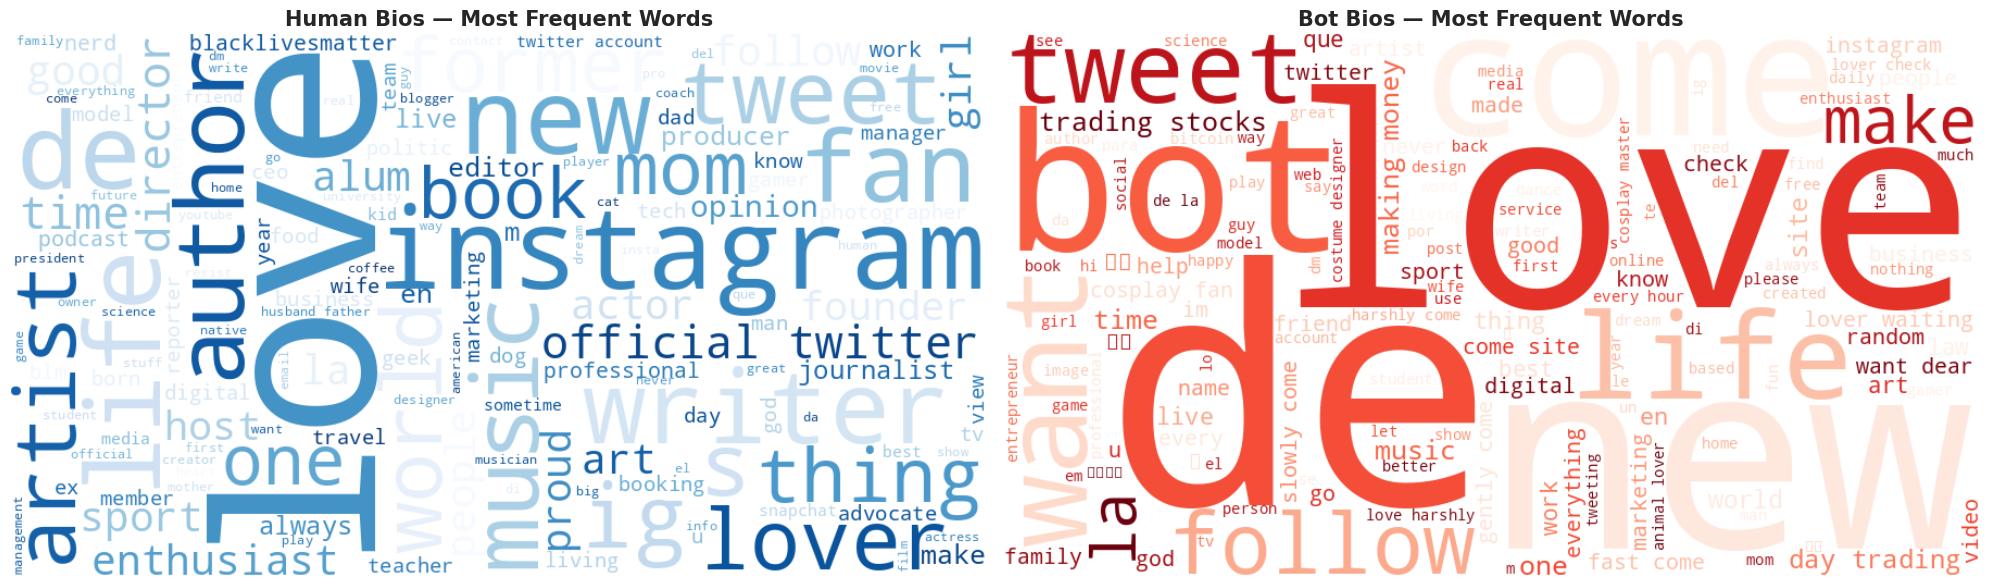

In [50]:
human_text = " ".join(df_engineered.loc[df_engineered["account_type"] == "human", "description_clean"])
bot_text = " ".join(df_engineered.loc[df_engineered["account_type"] == "bot", "description_clean"])

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

if len(human_text.strip()) > 0:
    wc_human = WordCloud(width=900, height=500, background_color="white",
                          colormap="Blues", max_words=150).generate(human_text)
    axes[0].imshow(wc_human, interpolation="bilinear")
axes[0].set_title("Human Bios — Most Frequent Words", fontsize=15, fontweight="bold")
axes[0].axis("off")

if len(bot_text.strip()) > 0:
    wc_bot = WordCloud(width=900, height=500, background_color="white",
                        colormap="Reds", max_words=150).generate(bot_text)
    axes[1].imshow(wc_bot, interpolation="bilinear")
axes[1].set_title("Bot Bios — Most Frequent Words", fontsize=15, fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 10.2 Most Common Words — Ranked Frequency Tables


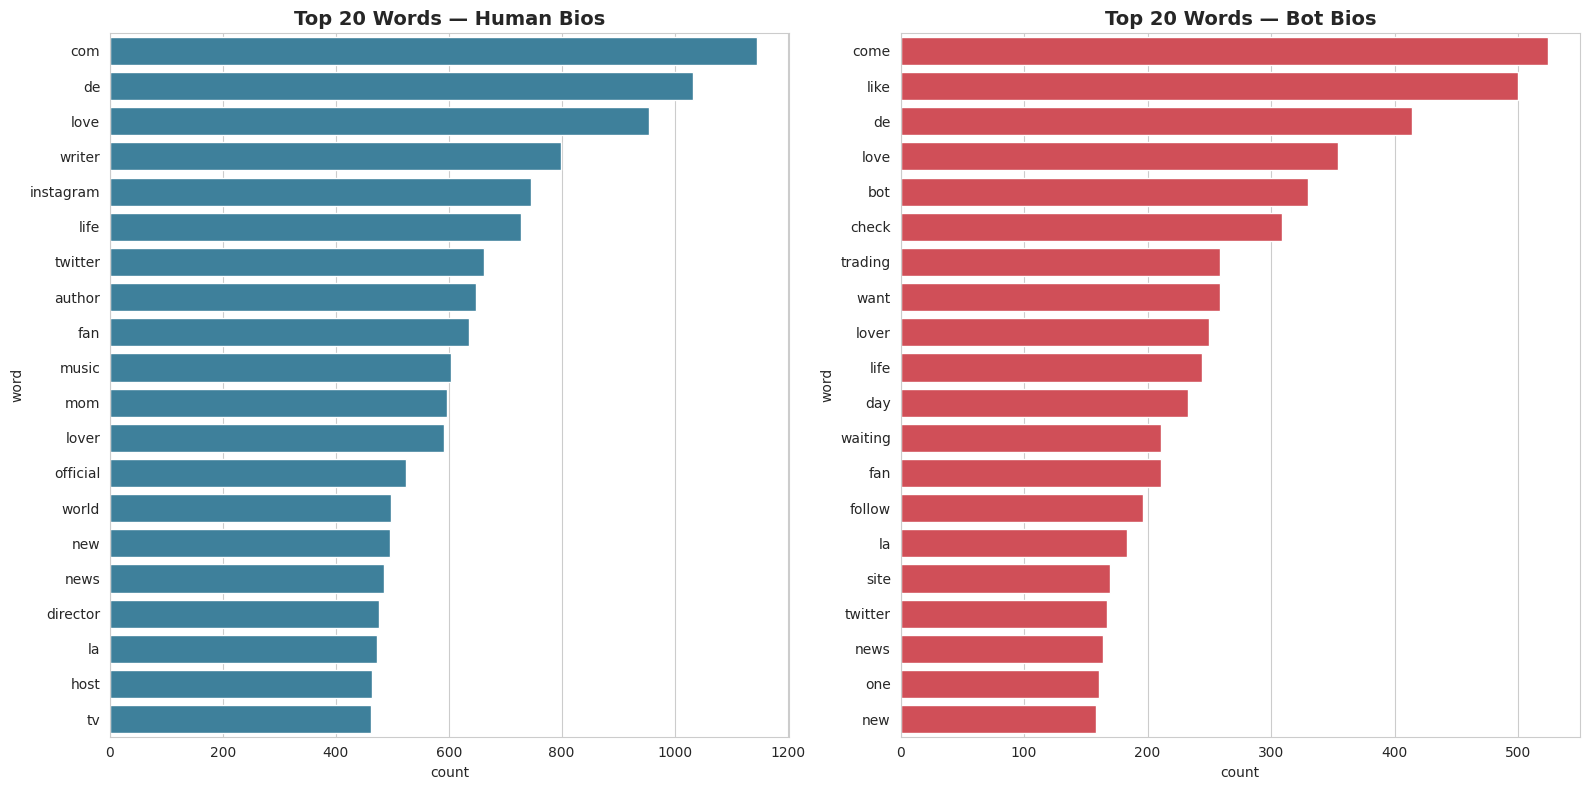

In [51]:
def top_n_words(text, n=20):
    words = text.split()
    counter = Counter(words)
    return pd.DataFrame(counter.most_common(n), columns=["word", "count"])

top_human_words = top_n_words(human_text, 20)
top_bot_words = top_n_words(bot_text, 20)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
sns.barplot(data=top_human_words, x="count", y="word", ax=axes[0], color=PALETTE["human"])
axes[0].set_title("Top 20 Words — Human Bios")

sns.barplot(data=top_bot_words, x="count", y="word", ax=axes[1], color=PALETTE["bot"])
axes[1].set_title("Top 20 Words — Bot Bios")

plt.tight_layout()
plt.show()

<a id="section11"></a>
# 11. Experiment 3 — NLP Model (Description Only)



In [52]:
X_text = df_engineered["description_clean"]
y_text = df_engineered["target"]

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text, y_text, test_size=0.2, random_state=RANDOM_STATE, stratify=y_text
)

tfidf_vectorizer = TfidfVectorizer(max_features=500, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

print(f"TF-IDF matrix shape — train: {X_train_tfidf.shape}, test: {X_test_tfidf.shape}")

TF-IDF matrix shape — train: (29950, 500), test: (7488, 500)


In [53]:
models_exp3 = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Linear SVM": CalibratedClassifierCV(LinearSVC(random_state=RANDOM_STATE, max_iter=5000), cv=3),
    "Multinomial Naive Bayes": MultinomialNB(),
}

nlp_results, fitted_models_exp3 = train_evaluate_models(
    models_exp3, X_train_tfidf, X_test_tfidf, y_train_text, y_test_text
)
print("Experiment 3 — NLP (Description Only) Leaderboard (sorted by F1 Score)")
style_leaderboard(nlp_results)

Experiment 3 — NLP (Description Only) Leaderboard (sorted by F1 Score)


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Multinomial Naive Bayes,0.7079,0.6966,0.2125,0.3256,0.7118
1,Logistic Regression,0.7141,0.7590,0.2028,0.3201,0.7554
2,Linear SVM,0.7139,0.7587,0.2024,0.3196,0.7549


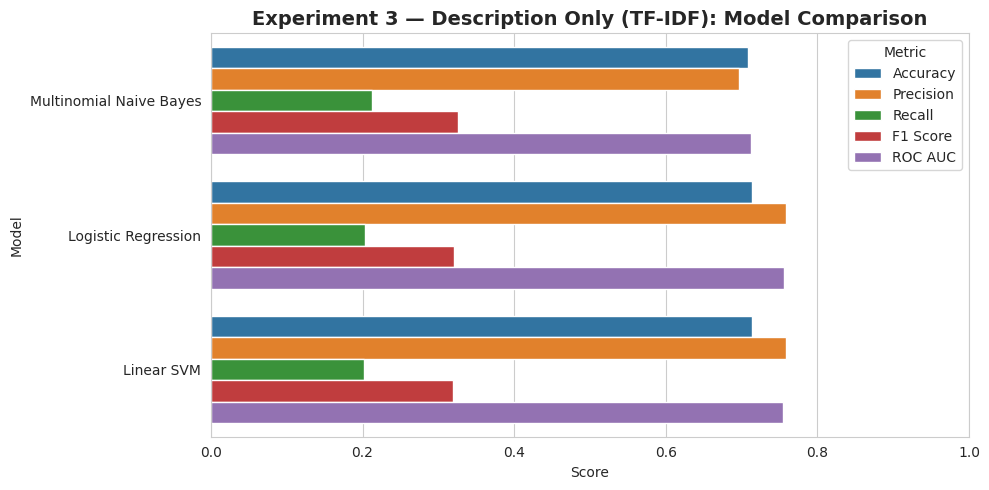

In [54]:
plot_leaderboard(nlp_results, "Experiment 3 — Description Only (TF-IDF): Model Comparison")

## 11.1 Most Predictive TF-IDF Terms (Logistic Regression Coefficients)


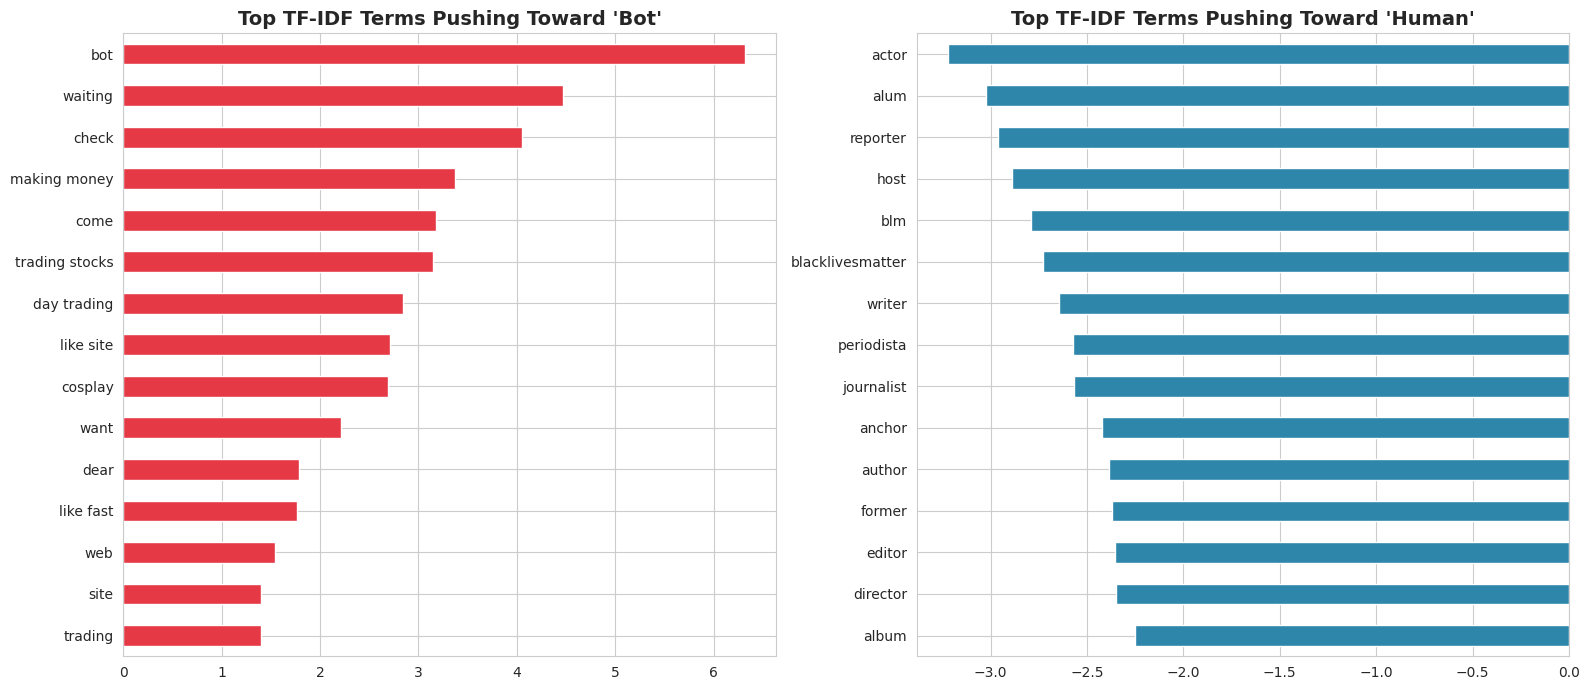

In [55]:
lr_text_model = models_exp3["Logistic Regression"]
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
coefs = lr_text_model.coef_[0]

top_bot_terms = pd.Series(coefs, index=feature_names).sort_values(ascending=False).head(15)
top_human_terms = pd.Series(coefs, index=feature_names).sort_values().head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
top_bot_terms.sort_values().plot(kind="barh", ax=axes[0], color=PALETTE["bot"])
axes[0].set_title("Top TF-IDF Terms Pushing Toward 'Bot'")

top_human_terms.sort_values(ascending=False).plot(kind="barh", ax=axes[1], color=PALETTE["human"])
axes[1].set_title("Top TF-IDF Terms Pushing Toward 'Human'")

plt.tight_layout()
plt.show()

<a id="section12"></a>
# 12. Final Comparison Across All Three Experiments



In [56]:
best_exp1 = baseline_results.iloc[0].copy()
best_exp1["Experiment"] = "1. Structured Only"

best_exp2 = engineered_feature_results.iloc[0].copy()
best_exp2["Experiment"] = "2. Structured + Description Features"

best_exp3 = nlp_results.iloc[0].copy()
best_exp3["Experiment"] = "3. Description Only (NLP)"

final_comparison = pd.DataFrame([best_exp1, best_exp2, best_exp3])
final_comparison = final_comparison[["Experiment", "Model", "Accuracy", "Precision",
                                      "Recall", "F1 Score", "ROC AUC"]].reset_index(drop=True)

print("=== FINAL COMPARISON — Best Model per Experiment ===")
final_comparison.style.format({
    "Accuracy": "{:.4f}", "Precision": "{:.4f}", "Recall": "{:.4f}",
    "F1 Score": "{:.4f}", "ROC AUC": "{:.4f}"
}).background_gradient(subset=["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"], cmap="Greens")

=== FINAL COMPARISON — Best Model per Experiment ===


,Experiment,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,1. Structured Only,LightGBM,0.8814,0.8513,0.7787,0.8134,0.9391
1,2. Structured + Description Features,LightGBM,0.8834,0.8585,0.7767,0.8156,0.9400
2,3. Description Only (NLP),Multinomial Naive Bayes,0.7079,0.6966,0.2125,0.3256,0.7118


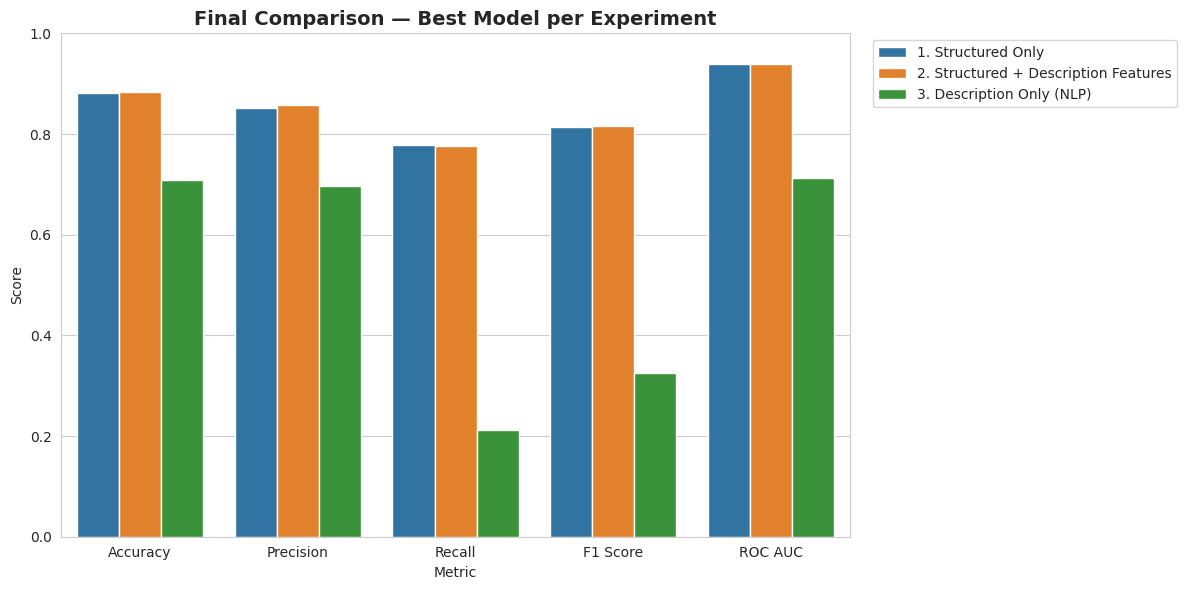

In [57]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_df = final_comparison.melt(id_vars=["Experiment", "Model"], var_name="Metric", value_name="Score")
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Experiment", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Final Comparison — Best Model per Experiment")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [58]:
fig = px.bar(
    plot_df, x="Metric", y="Score", color="Experiment", barmode="group",
    title="Final Comparison — Best Model per Experiment (Interactive)",
    color_discrete_sequence=["#264653", "#2A9D8F", "#E76F51"],
)
fig.update_layout(yaxis_range=[0, 1])
fig.show()

<a id="section13"></a>
# 13. Hyperparameter Tuning



In [59]:
best_model_name_exp2 = engineered_feature_results.iloc[0]["Model"]
print(f"Best Experiment 2 model selected for tuning: {best_model_name_exp2}")

Best Experiment 2 model selected for tuning: LightGBM


In [60]:
PARAM_DISTRIBUTIONS = {
    "Random Forest": {
        "n_estimators": [200, 300, 400, 500, 600],
        "max_depth": [None, 6, 10, 14, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2", None],
    },
    "XGBoost": {
        "n_estimators": [200, 300, 400, 500],
        "max_depth": [3, 4, 5, 6, 8],
        "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
    },
    "LightGBM": {
        "n_estimators": [200, 300, 400, 500],
        "num_leaves": [15, 31, 63, 127],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
    },
    "CatBoost": {
        "iterations": [200, 300, 400, 500],
        "depth": [4, 6, 8, 10],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "l2_leaf_reg": [1, 3, 5, 7],
    },
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],
        "penalty": ["l2"],
        "solver": ["lbfgs"],
    },
}

base_estimators = get_model_zoo()
estimator_to_tune = base_estimators[best_model_name_exp2]
param_distributions = PARAM_DISTRIBUTIONS.get(best_model_name_exp2, {})

search = RandomizedSearchCV(
    estimator=estimator_to_tune,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train_2_scaled, y_train2)

print("Best parameters found:")
print(search.best_params_)
print(f"\nBest cross-validated F1 score: {search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters found:
{'subsample': 0.8, 'num_leaves': 127, 'n_estimators': 400, 'learning_rate': 0.03, 'colsample_bytree': 0.6}

Best cross-validated F1 score: 0.8159


In [61]:
final_model = search.best_estimator_
y_pred_final = final_model.predict(X_test_2_scaled)
y_score_final = get_score(final_model, X_test_2_scaled)

tuned_metrics = evaluate_classification(y_test2, y_pred_final, y_score_final)
tuned_metrics["Model"] = f"{best_model_name_exp2} (Tuned)"

untuned_metrics = engineered_feature_results.iloc[0].to_dict()

tuning_comparison = pd.DataFrame([untuned_metrics, tuned_metrics])[
    ["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]
]
print("Before vs After Tuning:")
tuning_comparison.style.format({
    "Accuracy": "{:.4f}", "Precision": "{:.4f}", "Recall": "{:.4f}",
    "F1 Score": "{:.4f}", "ROC AUC": "{:.4f}"
})

Before vs After Tuning:


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,LightGBM,0.8834,0.8585,0.7767,0.8156,0.9400
1,LightGBM (Tuned),0.8821,0.8566,0.7742,0.8134,0.9418


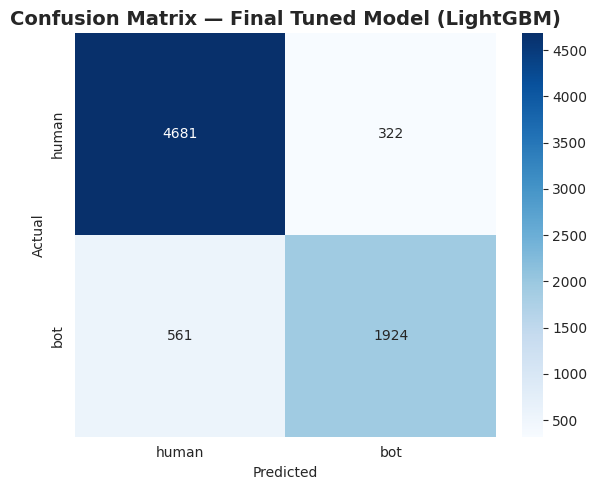

              precision    recall  f1-score   support

       human       0.89      0.94      0.91      5003
         bot       0.86      0.77      0.81      2485

    accuracy                           0.88      7488
   macro avg       0.87      0.85      0.86      7488
weighted avg       0.88      0.88      0.88      7488



In [62]:
cm_final = confusion_matrix(y_test2, y_pred_final)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_final, annot=True, fmt="d", cmap="Blues",
            xticklabels=["human", "bot"], yticklabels=["human", "bot"], ax=ax)
ax.set_title(f"Confusion Matrix — Final Tuned Model ({best_model_name_exp2})")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

print(classification_report(y_test2, y_pred_final, target_names=["human", "bot"]))

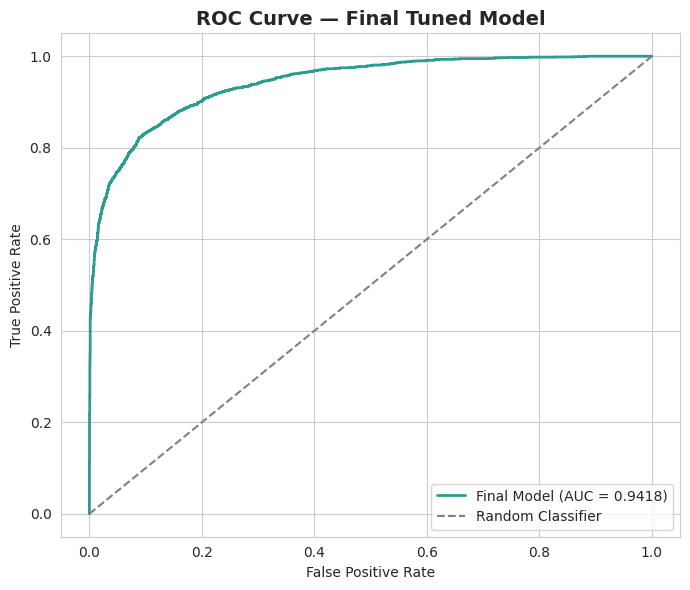

In [63]:
fpr, tpr, _ = roc_curve(y_test2, y_score_final)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="#2A9D8F", linewidth=2,
        label=f"Final Model (AUC = {tuned_metrics['ROC AUC']:.4f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random Classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Final Tuned Model")
ax.legend()
plt.tight_layout()
plt.show()

<a id="section14"></a>
# 14. Feature Importance



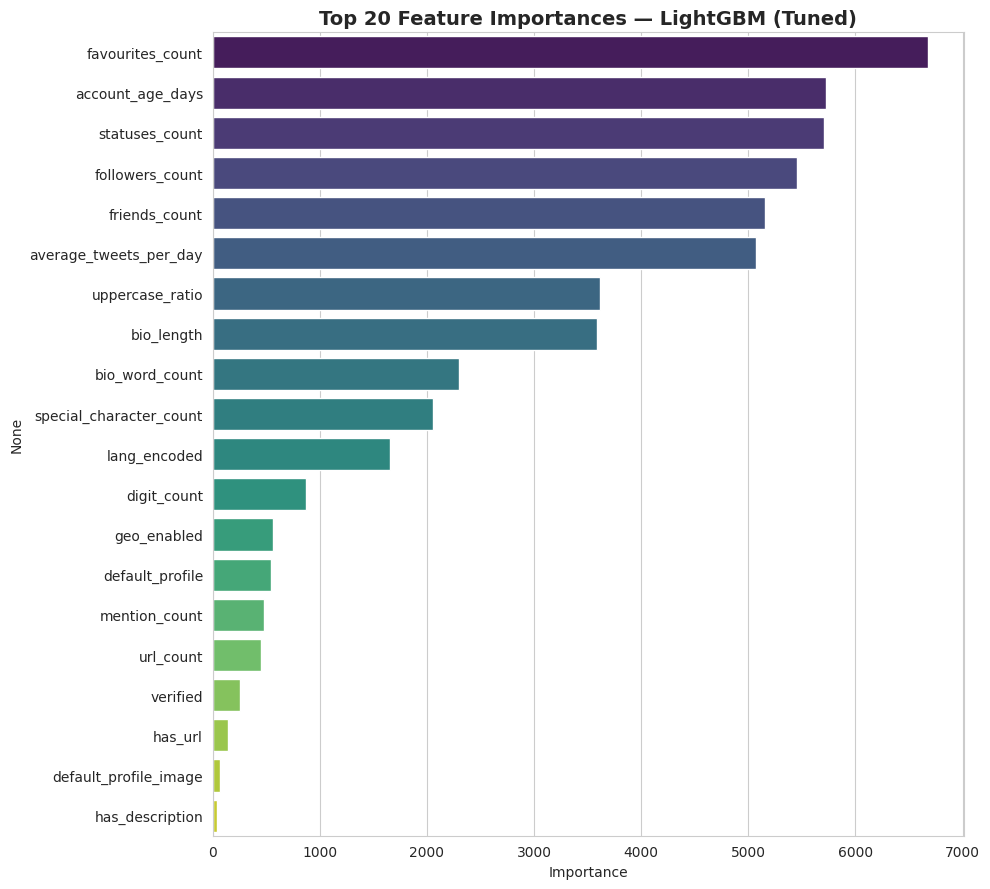

,importance
favourites_count,6680
account_age_days,5728
statuses_count,5703
followers_count,5450
friends_count,5152
average_tweets_per_day,5069
uppercase_ratio,3614
bio_length,3588
bio_word_count,2299
special_character_count,2057


In [64]:
def get_feature_importance(model, feature_names):
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    elif hasattr(model, "coef_"):
        importances = np.abs(model.coef_[0])
    else:
        raise ValueError("Model does not expose feature_importances_ or coef_")
    return pd.Series(importances, index=feature_names).sort_values(ascending=False)


feature_importance = get_feature_importance(final_model, X_train_2_scaled.columns)
top_20_features = feature_importance.head(20)

fig, ax = plt.subplots(figsize=(10, 9))
sns.barplot(x=top_20_features.values, y=top_20_features.index, ax=ax, palette="viridis")
ax.set_title(f"Top 20 Feature Importances — {best_model_name_exp2} (Tuned)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

top_20_features.to_frame("importance")

<a id="section15"></a>
# 15. SHAP Explainability



In [65]:
# Use a manageable background/explain sample for speed
shap_sample = X_test_2_scaled.sample(min(500, len(X_test_2_scaled)), random_state=RANDOM_STATE)

try:
    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(shap_sample)
    # Some libraries (e.g. older sklearn RF) return a list [class0, class1]
    if isinstance(shap_values, list):
        shap_values_plot = shap_values[1]
    else:
        shap_values_plot = shap_values
except Exception as e:
    print(f"TreeExplainer failed ({e}), falling back to general Explainer.")
    explainer = shap.Explainer(final_model, X_train_2_scaled.sample(min(200, len(X_train_2_scaled)),
                                                                      random_state=RANDOM_STATE))
    shap_values_plot = explainer(shap_sample)

print("SHAP values computed on", shap_sample.shape[0], "test samples.")

SHAP values computed on 500 test samples.


## 15.1 SHAP Summary Plot



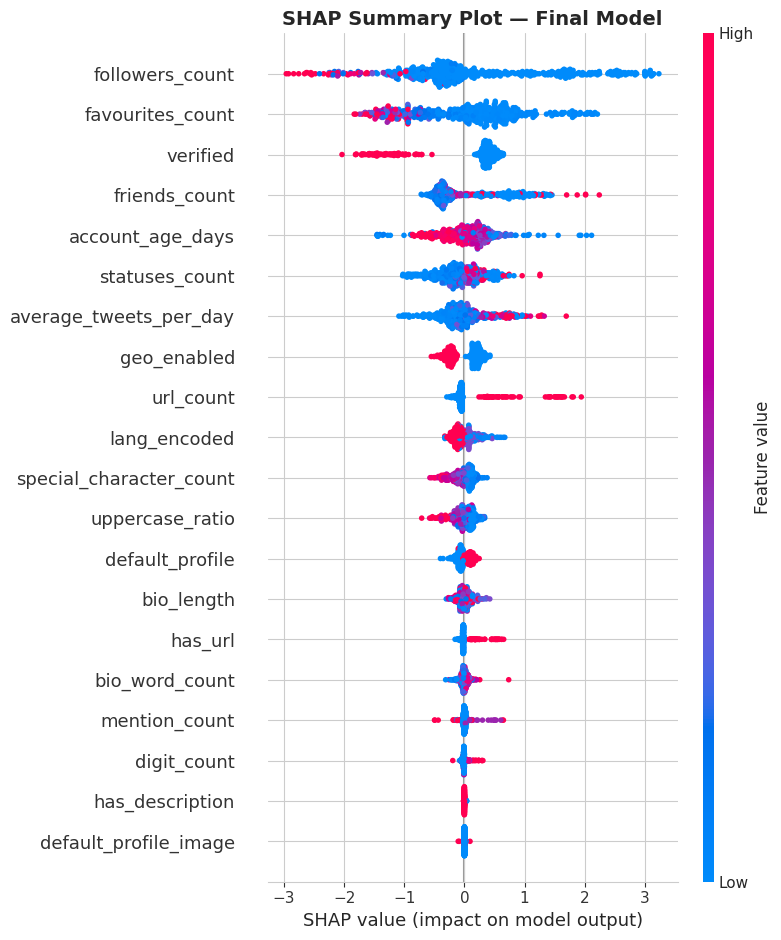

In [66]:
plt.figure(figsize=(10, 9))
shap.summary_plot(shap_values_plot, shap_sample, show=False)
plt.title("SHAP Summary Plot — Final Model")
plt.tight_layout()
plt.show()

## 15.2 SHAP Bar Plot (Mean Absolute Impact)


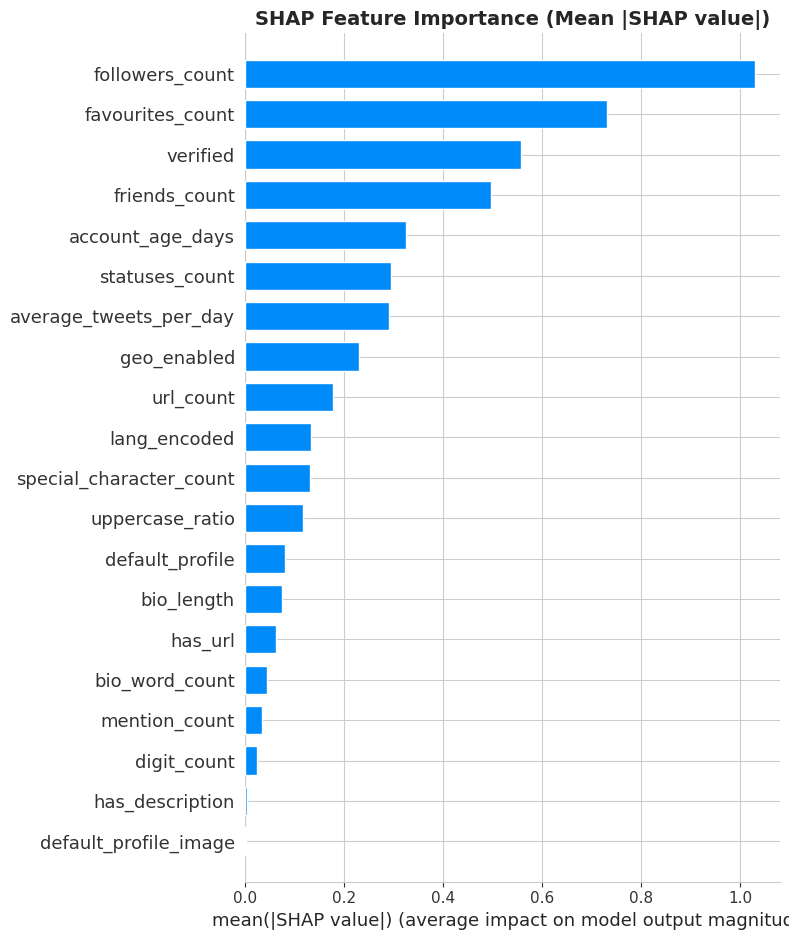

In [67]:
plt.figure(figsize=(10, 9))
shap.summary_plot(shap_values_plot, shap_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Mean |SHAP value|)")
plt.tight_layout()
plt.show()

<a id="section16"></a>
# 16. Save Artifacts



In [68]:
import os
os.makedirs("artifacts", exist_ok=True)

joblib.dump(final_model, "artifacts/best_model.joblib")
joblib.dump(scaler_exp2, "artifacts/scaler.joblib")
joblib.dump(lang_freq_map_2, "artifacts/lang_freq_map.joblib")
joblib.dump(tfidf_vectorizer, "artifacts/tfidf_vectorizer.joblib")
joblib.dump(list(X_train_2_scaled.columns), "artifacts/feature_columns.joblib")

print("Saved artifacts to ./artifacts/:")
for f in os.listdir("artifacts"):
    print(" -", f)

Saved artifacts to ./artifacts/:
 - tfidf_vectorizer.joblib
 - scaler.joblib
 - best_model.joblib
 - feature_columns.joblib
 - lang_freq_map.joblib


In [69]:
# Optional: download artifacts directly from Colab
try:
    from google.colab import files
    import shutil
    shutil.make_archive("artifacts", "zip", "artifacts")
    print("Artifacts zipped to artifacts.zip — run files.download('artifacts.zip') to download.")
except ImportError:
    print("Not running in Colab — artifacts are available locally in ./artifacts/")

Artifacts zipped to artifacts.zip — run files.download('artifacts.zip') to download.


<a id="section17"></a>
# 17. Streamlit App



**To run locally:**
```bash
pip install streamlit joblib pandas numpy scikit-learn xgboost lightgbm catboost
streamlit run app.py
```


In [71]:
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 16.9 MB/s eta 0:00:00


In [74]:
!ls artifacts

best_model.joblib	lang_freq_map.joblib  tfidf_vectorizer.joblib
feature_columns.joblib	scaler.joblib


In [75]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import re
import string

st.set_page_config(page_title="Twitter Bot Detector", page_icon="🐦", layout="centered")

# ---------------------------------------------------------------------------
# Load artifacts (produced in Section 16 of the notebook)
# ---------------------------------------------------------------------------
@st.cache_resource
def load_artifacts():
    model = joblib.load("artifacts/best_model.joblib")
    scaler = joblib.load("artifacts/scaler.joblib")
    lang_freq_map = joblib.load("artifacts/lang_freq_map.joblib")
    feature_columns = joblib.load("artifacts/feature_columns.joblib")
    return model, scaler, lang_freq_map, feature_columns

model, scaler, lang_freq_map, feature_columns = load_artifacts()

STOPWORDS_FALLBACK = set([
    "the", "a", "an", "and", "or", "but", "in", "on", "at", "to", "for",
    "of", "is", "are", "was", "were", "be", "been", "with", "i", "my", "me"
])


def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"[%s]" % re.escape(string.punctuation), " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [w for w in text.split() if w not in STOPWORDS_FALLBACK and len(w) > 1]
    return " ".join(tokens)


def engineer_description_features(text):
    text = text or ""
    features = {}
    features["bio_length"] = len(text)
    features["bio_word_count"] = len(text.split())
    features["has_description"] = int(text.strip() != "")
    features["mention_count"] = len(re.findall(r"@\w+", text))
    features["url_count"] = len(re.findall(r"http\S+|www\.\S+", text))
    features["has_url"] = int(features["url_count"] > 0)

    letters = [c for c in text if c.isalpha()]
    features["uppercase_ratio"] = (sum(1 for c in letters if c.isupper()) / len(letters)) if letters else 0.0
    features["digit_count"] = sum(c.isdigit() for c in text)
    features["special_character_count"] = sum(1 for c in text if not c.isalnum() and not c.isspace())
    return features


# ---------------------------------------------------------------------------
# UI
# ---------------------------------------------------------------------------
st.title("🐦 Twitter Bot Detector")
st.caption("Structured account metadata + bio-derived features → Human / Bot prediction")

st.sidebar.header("Account Features")

followers_count = st.sidebar.number_input("Followers count", min_value=0, value=150)
friends_count = st.sidebar.number_input("Friends (following) count", min_value=0, value=120)
statuses_count = st.sidebar.number_input("Statuses (tweets) count", min_value=0, value=500)
favourites_count = st.sidebar.number_input("Favourites (likes) count", min_value=0, value=200)
average_tweets_per_day = st.sidebar.number_input("Average tweets per day", min_value=0.0, value=2.5, step=0.1)
account_age_days = st.sidebar.number_input("Account age (days)", min_value=0, value=900)

verified = st.sidebar.checkbox("Verified account", value=False)
geo_enabled = st.sidebar.checkbox("Geo-location enabled", value=True)
default_profile = st.sidebar.checkbox("Using default profile theme", value=False)
default_profile_image = st.sidebar.checkbox("Using default profile image (no custom photo)", value=False)
has_location_input = st.sidebar.checkbox("Location field filled in", value=True)

lang = st.sidebar.text_input("Language code (e.g. en, es, fr)", value="en")

description = st.text_area(
    "Account bio / description",
    value="Coffee enthusiast, weekend hiker, and software engineer sharing thoughts on tech.",
    height=100,
)

if st.button("Predict", type="primary"):
    desc_features = engineer_description_features(description)

    row = {
        "default_profile": int(default_profile),
        "default_profile_image": int(default_profile_image),
        "favourites_count": favourites_count,
        "followers_count": followers_count,
        "friends_count": friends_count,
        "geo_enabled": int(geo_enabled),
        "statuses_count": statuses_count,
        "verified": int(verified),
        "average_tweets_per_day": average_tweets_per_day,
        "account_age_days": account_age_days,
        "has_location": int(has_location_input),
        "lang_encoded": lang_freq_map.get(lang.strip().lower(), 0.0),
        **desc_features,
    }

    input_df = pd.DataFrame([row])
    # Align column order with training data; fill any unseen-at-inference columns with 0
    input_df = input_df.reindex(columns=feature_columns, fill_value=0)

    input_scaled = pd.DataFrame(scaler.transform(input_df), columns=feature_columns)

    pred = model.predict(input_scaled)[0]
    proba = model.predict_proba(input_scaled)[0]
    bot_probability = proba[1]

    label = "🤖 BOT" if pred == 1 else "🧑 HUMAN"
    st.subheader(f"Prediction: {label}")
    st.metric("Bot probability", f"{bot_probability:.1%}")
    st.progress(float(bot_probability))

    st.markdown("### Top Contributing Factors")
    if hasattr(model, "feature_importances_"):
        importances = pd.Series(model.feature_importances_, index=feature_columns)
        contribution = (importances * np.abs(input_scaled.iloc[0])).sort_values(ascending=False).head(10)
        st.bar_chart(contribution)
        st.caption(
            "Bars show |scaled feature value| x global feature importance — an approximate, "
            "fast measure of which inputs most influenced this specific prediction. "
            "For exact, theoretically-grounded explanations, see the SHAP analysis in the notebook."
        )
    else:
        st.info("Feature-level contribution chart is only available for tree-based models.")

st.markdown("---")
st.caption(
    "This app reproduces the Experiment 2 pipeline (Structured Data + Description Features) "
    "from the 'Twitter Bot Detection Using Machine Learning and NLP' notebook."
)


Overwriting app.py


In [79]:
!pip install pyngrok -q

In [80]:
from pyngrok import ngrok

ngrok.set_auth_token("Your Authtoken")

In [81]:
from pyngrok import ngrok
import subprocess
import time

!pkill -f streamlit

process = subprocess.Popen(
    ["streamlit", "run", "app.py", "--server.port", "8501"]
)

time.sleep(5)

url = ngrok.connect(8501)

print(url)

NgrokTunnel: "https://appendage-hammock-stoplight.ngrok-free.dev" -> "http://localhost:8501"
